# Only for papers

In [215]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Heat Data
heat_data = pd.read_csv('heat_eq_new.csv', header=None).to_numpy()
heat_CS_data = pd.read_csv('Reconstructed_State_Heat.csv', header=None).to_numpy()
heat_input_Data = pd.read_csv('input_heat_eq_new.csv',header=None).to_numpy()

# SST Data
sst_data = pd.read_csv('SST_data.csv', header=None).to_numpy()
sst_CS_data = pd.read_csv('Reconstructed_State_SST.csv', header=None).to_numpy()

# Burgers Data
burgers_data = pd.read_csv('burger_state_20000x1000.csv', header=None).to_numpy()
burgers_CS_data = pd.read_csv('Reconstructed_State_burgers_1000_new.csv', header=None).to_numpy()
burgers_input_Data = pd.read_csv('burger_input_1000.csv', header=None).to_numpy()

#### Sparse Images


In [ ]:
import numpy as np

# ==================================================
# RANDOM 10% SPATIAL SENSOR SAMPLING
# ==================================================

sensor_ratio = 0.10
rng = np.random.default_rng(42)   # reproducible random sensors

# -------------------------------
# Heat data
# heat_data shape: 10201 x T
# grid: 101 x 101
# -------------------------------
N_heat, T_heat = heat_data.shape
m_heat = int(sensor_ratio * N_heat)

heat_sensor_idx = rng.choice(N_heat, size=m_heat, replace=False)

heat_sparse = np.full_like(heat_data, np.nan, dtype=float)
heat_sparse[heat_sensor_idx, :] = heat_data[heat_sensor_idx, :]


# -------------------------------
# SST data
# You need to define ny_sst and nx_sst
# Example: if SST_data has N = ny_sst * nx_sst
# -------------------------------
N_sst, T_sst = sst_data.shape
m_sst = int(sensor_ratio * N_sst)

sst_sensor_idx = rng.choice(N_sst, size=m_sst, replace=False)

sst_sparse = np.full_like(sst_data, np.nan, dtype=float)
sst_sparse[sst_sensor_idx, :] = sst_data[sst_sensor_idx, :]


# -------------------------------
# Burgers data
# burgers_data shape: 20000 x T
# grid: 100 x 200
# -------------------------------
N_burgers, T_burgers = burgers_data.shape
m_burgers = int(sensor_ratio * N_burgers)

burgers_sensor_idx = rng.choice(N_burgers, size=m_burgers, replace=False)

burgers_sparse = np.full_like(burgers_data, np.nan, dtype=float)
burgers_sparse[burgers_sensor_idx, :] = burgers_data[burgers_sensor_idx, :]

## Compressed Sensing Visualization

#### Burgers

burgers sparse at t=290: min=-0.207, max=0.386


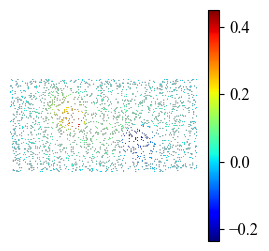

burgers GT at t=290: min=-0.209, max=0.434


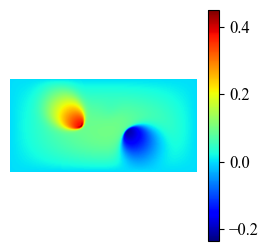

burgers CS at t=290: min=-0.213, max=0.367


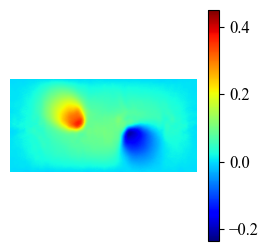

scatter plot of GT vs CS at t=290


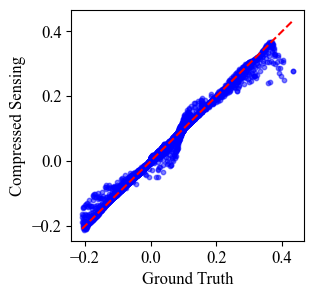

Overall RMSE for Burgers CS Reconstruction: 0.0048
Total Relative Error (TRE) for Burgers CS Reconstruction: 4.0941


In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({
    "font.size": 12,
    "font.family": "Times New Roman"
})
# Burgers Data
burgers_index = 290
print(f'burgers sparse at t={burgers_index}: min={burgers_sparse[:, burgers_index][~np.isnan(burgers_sparse[:, burgers_index])].min():.3f}, max={burgers_sparse[:, burgers_index][~np.isnan(burgers_sparse[:, burgers_index])].max():.3f}')
plt.figure(figsize=(3, 3))
plt.imshow(burgers_sparse[:, burgers_index].reshape(100, 200), cmap='jet', vmin = burgers_data.min(), vmax = burgers_data.max())
# plt.title(f'Burgers Sparse Sensors (t={burgers_index})')
plt.axis('off')
#plt.colorbar
plt.show()
print(f'burgers GT at t={burgers_index}: min={burgers_data[:, burgers_index].min():.3f}, max={burgers_data[:, burgers_index].max():.3f}')
plt.figure(figsize=(3, 3))
plt.imshow(burgers_data[:, burgers_index].reshape(100, 200), cmap='jet', vmin = burgers_data.min(), vmax = burgers_data.max())
# plt.title(f'Burgers GT (t={burgers_index})')
plt.axis('off')
#plt.colorbar
plt.show()
print(f'burgers CS at t={burgers_index}: min={burgers_CS_data[:, burgers_index].min():.3f}, max={burgers_CS_data[:, burgers_index].max():.3f}')
plt.figure(figsize=(3, 3))
plt.imshow(burgers_CS_data[:, burgers_index].reshape(100, 200), cmap='jet', vmin = burgers_data.min(), vmax = burgers_data.max())
# plt.title(f'Burgers CS Reconstruction (t={burgers_index})')
plt.axis('off')
#plt.colorbar
plt.show()
print(f'scatter plot of GT vs CS at t={burgers_index}')
plt.figure(figsize=(3, 3))
plt.scatter(burgers_data[:, burgers_index], burgers_CS_data[:, burgers_index], c='blue', s=10, alpha=0.5)
plt.plot([burgers_data[:, burgers_index].min(), burgers_data[:, burgers_index].max()], [burgers_data[:, burgers_index].min(), burgers_data[:, burgers_index].max()], 'r--')  # Add y=x line for reference
plt.xlabel('Ground Truth')
plt.ylabel('Compressed Sensing')
plt.show()

# Overall RMSE
rmse_burgers = np.sqrt(np.mean((burgers_data[:,:burgers_index] - burgers_CS_data[:,:burgers_index]) ** 2))
print(f'Overall RMSE for Burgers CS Reconstruction: {rmse_burgers:.4f}')

# Total Relative Error
TRE = 100* np.sum(np.abs(burgers_data[:,:burgers_index] - burgers_CS_data[:,:burgers_index])) / np.sum(np.abs(burgers_data[:,:burgers_index]))
print(f'Total Relative Error (TRE) for Burgers CS Reconstruction: {TRE:.4f}')

#### Heat

heat sparse at t=300: min=3.051, max=77.504


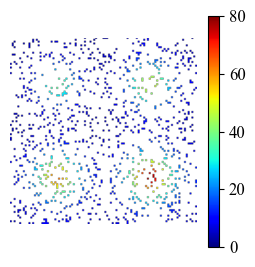

heat GT at t=300: min=3.003, max=78.820


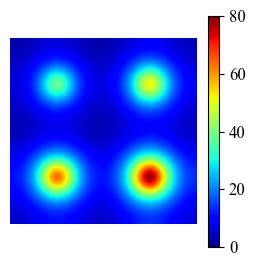

heat CS at t=300: min=2.934, max=74.619


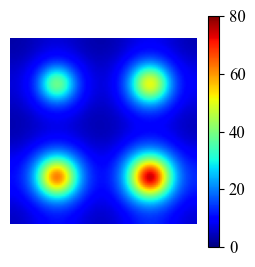

scatter plot of GT vs CS at t=300


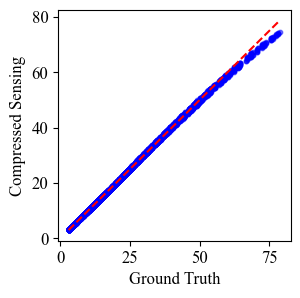

Overall RMSE for Heat CS Reconstruction: 0.3121
Total Relative Error (TRE) for Heat CS Reconstruction: 1.7198%


In [ ]:
heat_index = 300
plt.figure(figsize=(3, 3))
print(f'heat sparse at t={heat_index}: min={heat_sparse[:, heat_index][~np.isnan(heat_sparse[:, heat_index])].min():.3f}, max={heat_sparse[:, heat_index][~np.isnan(heat_sparse[:, heat_index])].max():.3f}')
plt.imshow(heat_sparse[:, heat_index].reshape(101, 101), cmap='jet', vmin = heat_data.min(), vmax = 80)
# plt.title(f'Heat Sparse Sensors (t={heat_index})')
plt.axis('off')
#plt.colorbar
plt.show()
print(f'heat GT at t={heat_index}: min={heat_data[:, heat_index].min():.3f}, max={heat_data[:, heat_index].max():.3f}')
plt.figure(figsize=(3, 3))
plt.imshow(heat_data[:, heat_index].reshape(101, 101), cmap='jet', vmin = heat_data.min(), vmax = 80)
# plt.title(f'Heat GT (t={heat_index})')
plt.axis('off')
#plt.colorbar
plt.show()
print(f'heat CS at t={heat_index}: min={heat_CS_data[:, heat_index].min():.3f}, max={heat_CS_data[:, heat_index].max():.3f}')
plt.figure(figsize=(3, 3))
plt.imshow(heat_CS_data[:, heat_index].reshape(101, 101), cmap='jet', vmin = heat_data.min(), vmax = 80)
# plt.title(f'Heat CS Reconstruction (t={heat_index})')
plt.axis('off')
#plt.colorbar
plt.show()
print(f'scatter plot of GT vs CS at t={heat_index}')
plt.figure(figsize=(3, 3))
plt.scatter(heat_data[:, heat_index], heat_CS_data[:, heat_index], c='blue', s=10, alpha=0.5)
plt.plot([heat_data[:, heat_index].min(), heat_data[:, heat_index].max()], [heat_data[:, heat_index].min(), heat_data[:, heat_index].max()], 'r--')  # Add y=x line for reference
plt.xlabel('Ground Truth')
plt.ylabel('Compressed Sensing')
plt.show()

# Overall RMSE
rmse_heat = np.sqrt(np.mean((heat_data[:,:heat_index] - heat_CS_data[:,:heat_index]) ** 2))
print(f'Overall RMSE for Heat CS Reconstruction: {rmse_heat:.4f}')  

# Total Relative Error
TRE_heat = 100* np.sum(np.abs(heat_data[:,:heat_index] - heat_CS_data[:,:heat_index])) / np.sum(np.abs(heat_data[:,:heat_index]))
print(f'Total Relative Error (TRE) for Heat CS Reconstruction: {TRE_heat:.4f}%')

#### SST

sst sparse at t=300: min=18.740, max=29.880


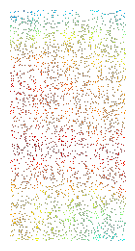

sst GT at t=300: min=18.740, max=29.910


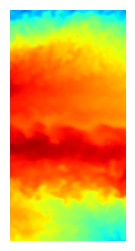

IndexError: index 300 is out of bounds for axis 1 with size 150

In [200]:
sst_index = 300
plt.figure(figsize=(3, 3))
print(f'sst sparse at t={sst_index}: min={sst_sparse[:, sst_index][~np.isnan(sst_sparse[:, sst_index])].min():.3f}, max={sst_sparse[:, sst_index][~np.isnan(sst_sparse[:, sst_index])].max():.3f}')
plt.imshow(sst_sparse[:, sst_index].reshape(240, 120), cmap='jet', vmin = sst_data.min(), vmax = sst_data.max())
# plt.title(f'SST Sparse Sensors (t={sst_index})')
plt.axis('off')
#plt.colorbar
plt.show()
print(f'sst GT at t={sst_index}: min={sst_data[:, sst_index].min():.3f}, max={sst_data[:, sst_index].max():.3f}')
plt.figure(figsize=(3, 3))
plt.imshow(sst_data[:, sst_index].reshape(240, 120), cmap='jet', vmin = sst_data.min(), vmax = sst_data.max())
# plt.title(f'SST GT (t={sst_index})')
plt.axis('off')
#plt.colorbar
plt.show()
print(f'sst CS at t={sst_index}: min={sst_CS_data[:, sst_index].min():.3f}, max={sst_CS_data[:, sst_index].max():.3f}')
plt.figure(figsize=(3, 3))
plt.imshow(sst_CS_data[:, sst_index].reshape(240, 120), cmap='jet', vmin = sst_data.min(), vmax = sst_data.max())
# plt.title(f'SST CS Reconstruction (t={sst_index})')
plt.axis('off')
#plt.colorbar
plt.show()
print(f'scatter plot of GT vs CS at t={sst_index}')
plt.figure(figsize=(3, 3))
plt.scatter(sst_data[:, sst_index], sst_CS_data[:, sst_index], c='blue', s=10, alpha=0.5)
plt.plot([sst_data[:, sst_index].min(), sst_data[:, sst_index].max()], [sst_data[:, sst_index].min(), sst_data[:, sst_index].max()], 'r--')  # Add y=x line for reference
plt.xlabel('Ground Truth')
plt.ylabel('Compressed Sensing')
plt.show()

# Overall RMSE
rmse_sst = np.sqrt(np.mean((sst_data[:,:sst_index] - sst_CS_data[:,:sst_index]) ** 2))
print(f'Overall RMSE for SST CS Reconstruction: {rmse_sst:.4f}')
# Total Relative Error
TRE_sst = 100* np.sum(np.abs(sst_data[:,:sst_index] - sst_CS_data[:,:sst_index])) / np.sum(np.abs(sst_data[:,:sst_index]))
print(f'Total Relative Error (TRE) for SST CS Reconstruction: {TRE_sst:.4f}%')


burgers sparse at t=290: min=-0.207, max=0.386


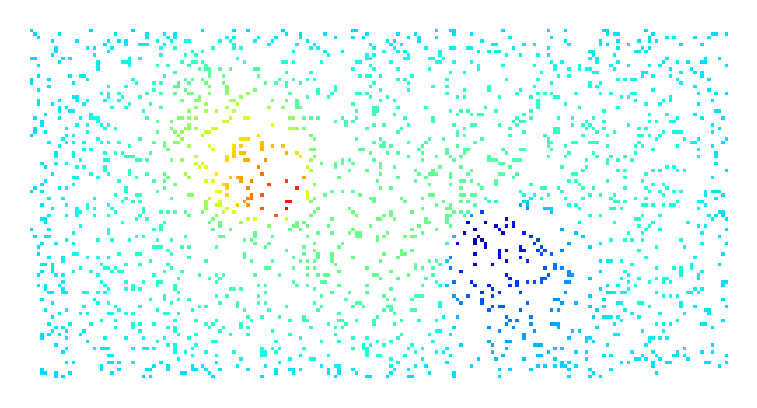

burgers GT at t=290: min=-0.209, max=0.434


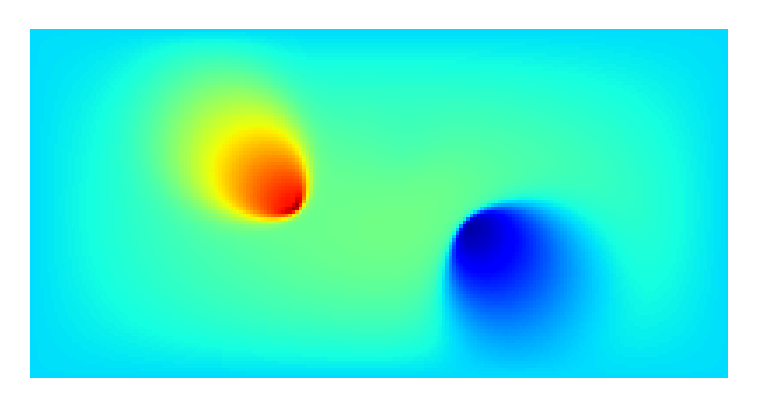

burgers CS at t=290: min=-0.209, max=0.382


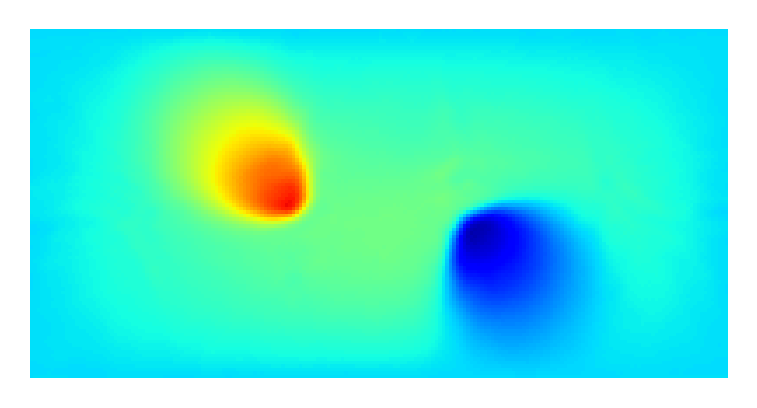

scatter plot of GT vs CS at t=290


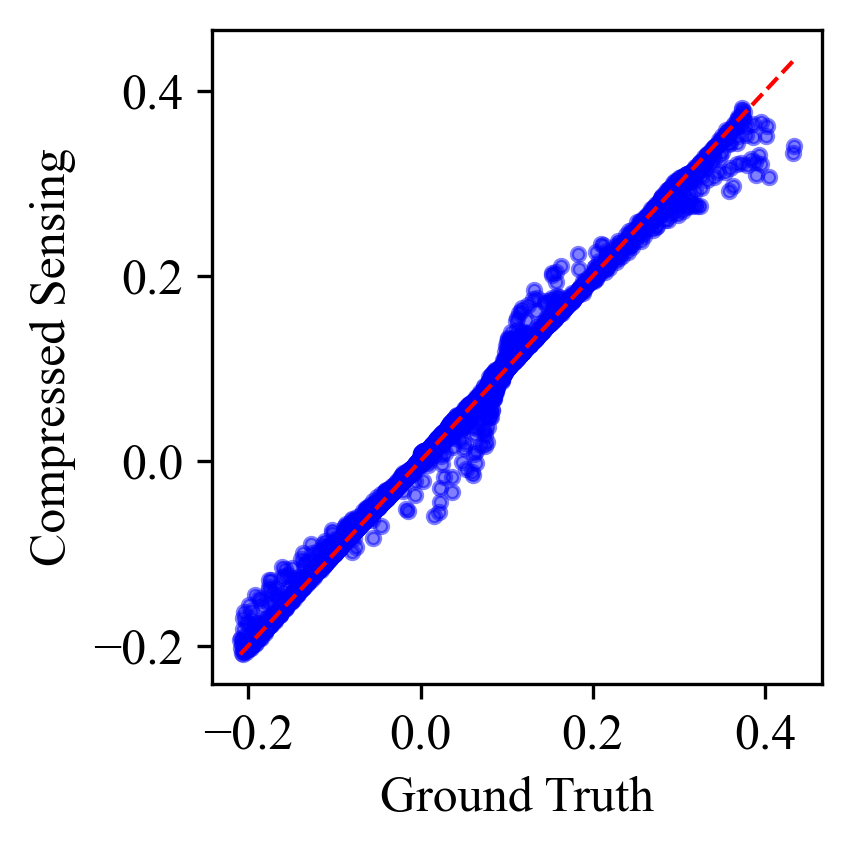

Overall RMSE for Burgers CS Reconstruction: 0.0031
Total Relative Error (TRE) for Burgers CS Reconstruction: 2.3180%
heat sparse at t=300: min=3.051, max=77.504


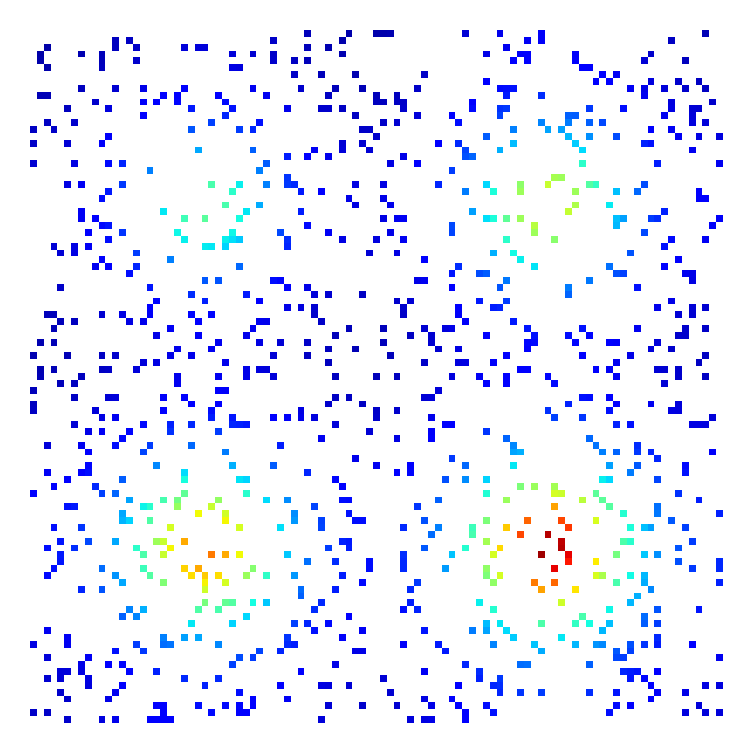

heat GT at t=300: min=3.003, max=78.820


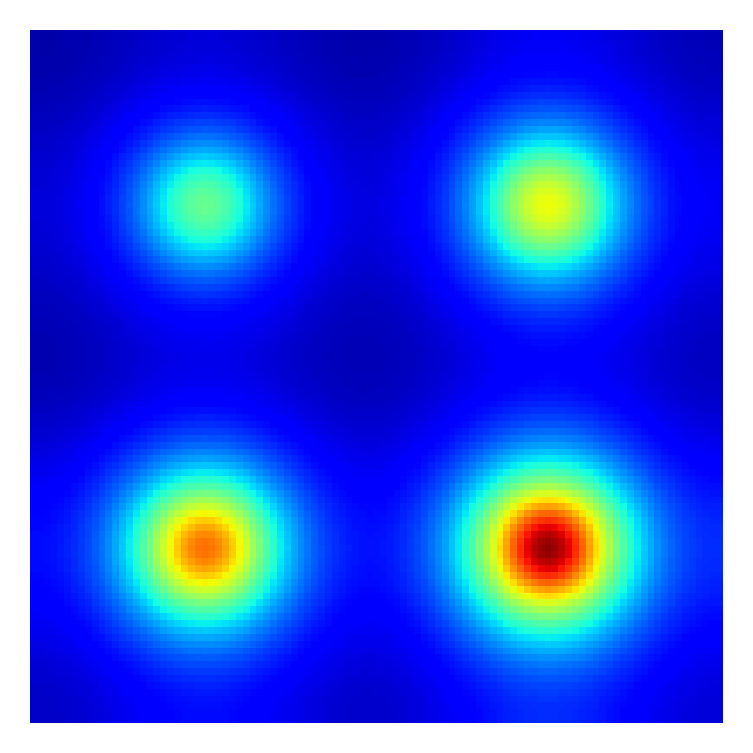

heat CS at t=300: min=2.934, max=74.619


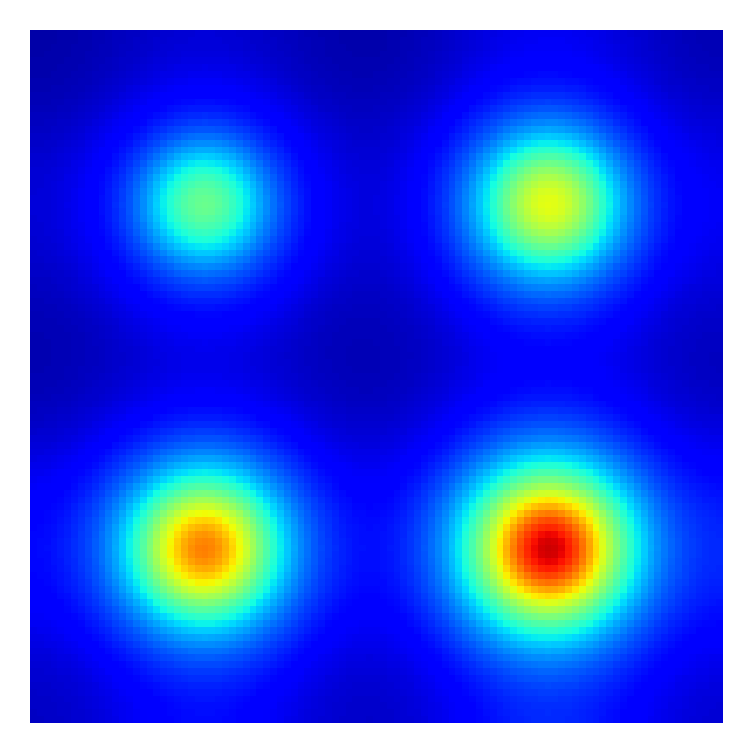

scatter plot of GT vs CS at t=300


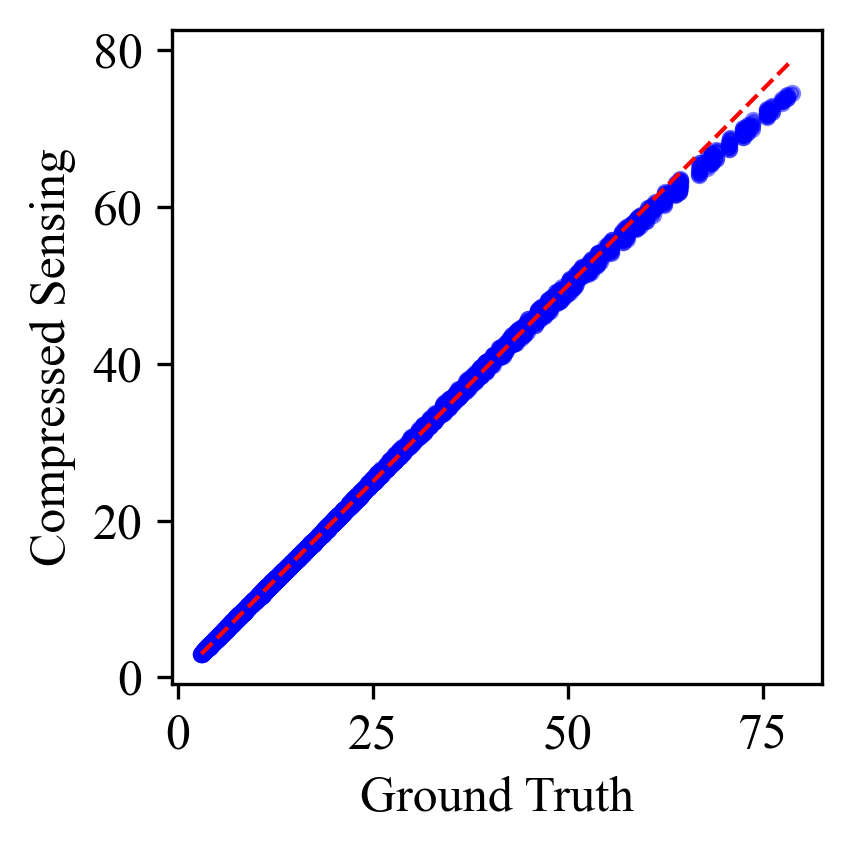

Overall RMSE for Heat CS Reconstruction: 0.3121
Total Relative Error (TRE) for Heat CS Reconstruction: 1.7198%
sst sparse at t=50: min=15.790, max=29.150


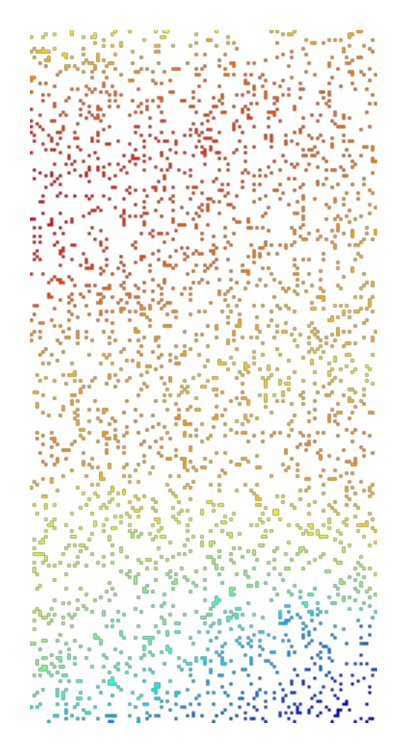

sst GT at t=50: min=15.630, max=29.170


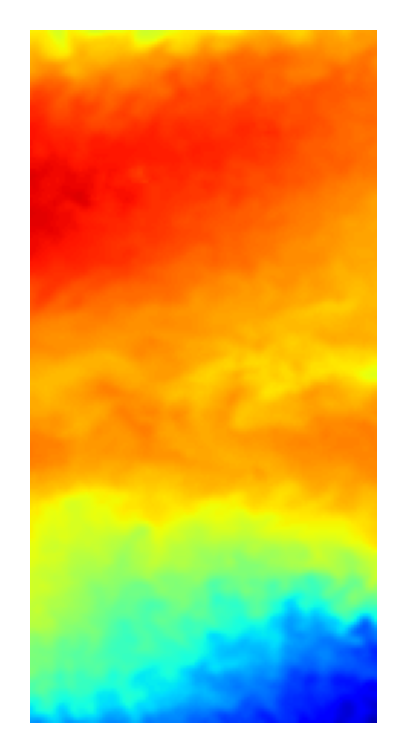

sst CS at t=50: min=15.740, max=29.135


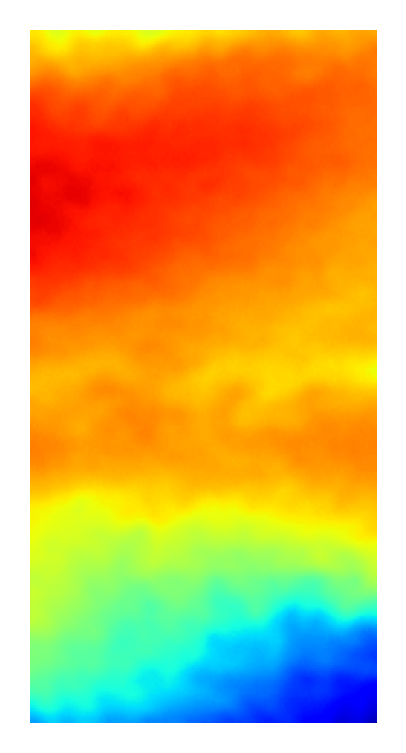

scatter plot of GT vs CS at t=50


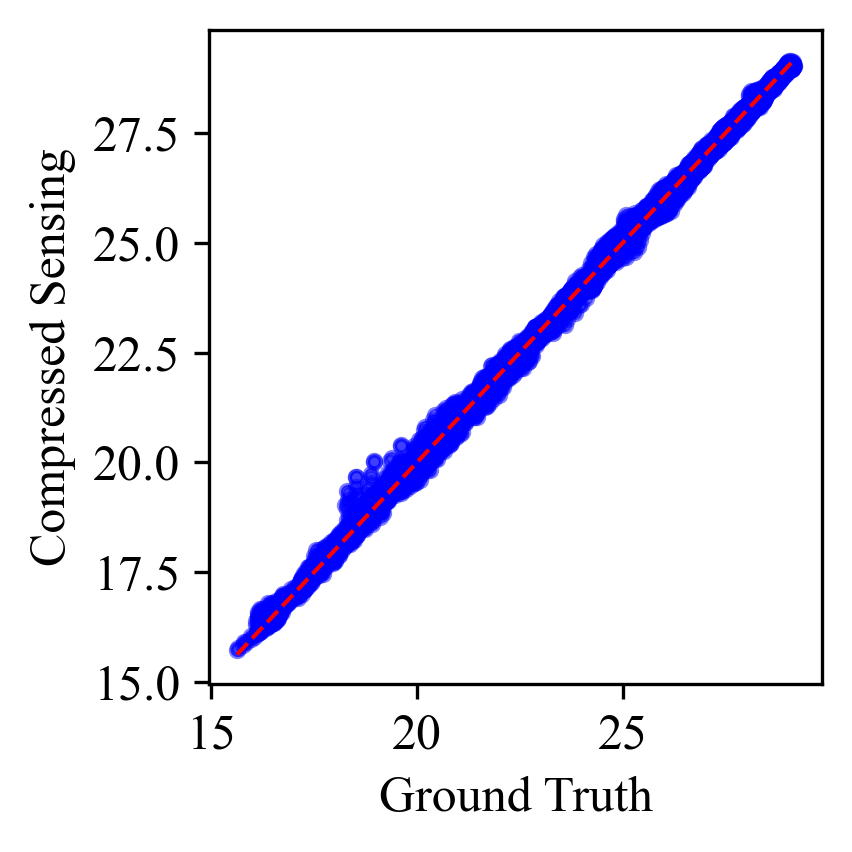

Overall RMSE for SST CS Reconstruction: 0.0923
Total Relative Error (TRE) for SST CS Reconstruction: 0.2617%


In [76]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# SAVE DIRECTORY
# ==================================================
save_dir = "Paper Figures/Compressed Sensing"
os.makedirs(save_dir, exist_ok=True)

plt.rcParams.update({
    "font.size": 12,
    "font.family": "Times New Roman"
})

# ==================================================
# HELPER FUNCTION FOR FIELD PLOTS
# ==================================================
def save_field_plot(data_vector, shape, cmap, vmin, vmax, filename):
    fig, ax = plt.subplots(figsize=(3, 3), dpi=300)

    im = ax.imshow(
        data_vector.reshape(shape),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    ax.axis('off')

    plt.savefig(
        os.path.join(save_dir, filename),
        dpi=600,
        bbox_inches='tight',
        pad_inches=0.02
    )

    plt.show()
    plt.close(fig)

# ==================================================
# HELPER FUNCTION FOR SCATTER PLOTS
# ==================================================
def save_scatter_plot(gt, cs, filename):
    fig, ax = plt.subplots(figsize=(3, 3), dpi=300)

    ax.scatter(gt, cs, c='blue', s=10, alpha=0.5)

    min_val = gt.min()
    max_val = gt.max()

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        'r--',
        linewidth=1
    )

    ax.set_xlabel('Ground Truth')
    ax.set_ylabel('Compressed Sensing')

    plt.tight_layout()

    plt.savefig(
        os.path.join(save_dir, filename),
        dpi=600,
        bbox_inches='tight',
        pad_inches=0.02
    )

    plt.show()
    plt.close(fig)


# ==================================================
# BURGERS DATA
# ==================================================
burgers_index = 290

print(f'burgers sparse at t={burgers_index}: min={burgers_sparse[:, burgers_index][~np.isnan(burgers_sparse[:, burgers_index])].min():.3f}, max={burgers_sparse[:, burgers_index][~np.isnan(burgers_sparse[:, burgers_index])].max():.3f}')

save_field_plot(
    burgers_sparse[:, burgers_index],
    shape=(100, 200),
    cmap='jet',
    vmin=burgers_data.min(),
    vmax=burgers_data.max(),
    filename=f"burgers_sparse_t{burgers_index}.png"
)

print(f'burgers GT at t={burgers_index}: min={burgers_data[:, burgers_index].min():.3f}, max={burgers_data[:, burgers_index].max():.3f}')

save_field_plot(
    burgers_data[:, burgers_index],
    shape=(100, 200),
    cmap='jet',
    vmin=burgers_data.min(),
    vmax=burgers_data.max(),
    filename=f"burgers_GT_t{burgers_index}.png"
)

print(f'burgers CS at t={burgers_index}: min={burgers_CS_data[:, burgers_index].min():.3f}, max={burgers_CS_data[:, burgers_index].max():.3f}')

save_field_plot(
    burgers_CS_data[:, burgers_index],
    shape=(100, 200),
    cmap='jet',
    vmin=burgers_data.min(),
    vmax=burgers_data.max(),
    filename=f"burgers_CS_t{burgers_index}.png"
)

print(f'scatter plot of GT vs CS at t={burgers_index}')

save_scatter_plot(
    burgers_data[:, burgers_index],
    burgers_CS_data[:, burgers_index],
    filename=f"burgers_GT_vs_CS_t{burgers_index}.png"
)

rmse_burgers = np.sqrt(np.mean((burgers_data[:, :burgers_index] - burgers_CS_data[:, :burgers_index]) ** 2))
print(f'Overall RMSE for Burgers CS Reconstruction: {rmse_burgers:.4f}')

TRE_burgers = 100 * np.sum(np.abs(burgers_data[:, :burgers_index] - burgers_CS_data[:, :burgers_index])) / np.sum(np.abs(burgers_data[:, :burgers_index]))
print(f'Total Relative Error (TRE) for Burgers CS Reconstruction: {TRE_burgers:.4f}%')


# ==================================================
# HEAT DATA
# ==================================================
heat_index = 300

print(f'heat sparse at t={heat_index}: min={heat_sparse[:, heat_index][~np.isnan(heat_sparse[:, heat_index])].min():.3f}, max={heat_sparse[:, heat_index][~np.isnan(heat_sparse[:, heat_index])].max():.3f}')

save_field_plot(
    heat_sparse[:, heat_index],
    shape=(101, 101),
    cmap='jet',
    vmin=heat_data.min(),
    vmax=80,
    filename=f"heat_sparse_t{heat_index}.png"
)

print(f'heat GT at t={heat_index}: min={heat_data[:, heat_index].min():.3f}, max={heat_data[:, heat_index].max():.3f}')

save_field_plot(
    heat_data[:, heat_index],
    shape=(101, 101),
    cmap='jet',
    vmin=heat_data.min(),
    vmax=80,
    filename=f"heat_GT_t{heat_index}.png"
)

print(f'heat CS at t={heat_index}: min={heat_CS_data[:, heat_index].min():.3f}, max={heat_CS_data[:, heat_index].max():.3f}')

save_field_plot(
    heat_CS_data[:, heat_index],
    shape=(101, 101),
    cmap='jet',
    vmin=heat_data.min(),
    vmax=80,
    filename=f"heat_CS_t{heat_index}.png"
)

print(f'scatter plot of GT vs CS at t={heat_index}')

save_scatter_plot(
    heat_data[:, heat_index],
    heat_CS_data[:, heat_index],
    filename=f"heat_GT_vs_CS_t{heat_index}.png"
)

rmse_heat = np.sqrt(np.mean((heat_data[:, :heat_index] - heat_CS_data[:, :heat_index]) ** 2))
print(f'Overall RMSE for Heat CS Reconstruction: {rmse_heat:.4f}')

TRE_heat = 100 * np.sum(np.abs(heat_data[:, :heat_index] - heat_CS_data[:, :heat_index])) / np.sum(np.abs(heat_data[:, :heat_index]))
print(f'Total Relative Error (TRE) for Heat CS Reconstruction: {TRE_heat:.4f}%')


# ==================================================
# SST DATA
# ==================================================
sst_index = 50

print(f'sst sparse at t={sst_index}: min={sst_sparse[:, sst_index][~np.isnan(sst_sparse[:, sst_index])].min():.3f}, max={sst_sparse[:, sst_index][~np.isnan(sst_sparse[:, sst_index])].max():.3f}')

save_field_plot(
    sst_sparse[:, sst_index],
    shape=(240, 120),
    cmap='jet',
    vmin=sst_data.min(),
    vmax=sst_data.max(),
    filename=f"sst_sparse_t{sst_index}.png"
)

print(f'sst GT at t={sst_index}: min={sst_data[:, sst_index].min():.3f}, max={sst_data[:, sst_index].max():.3f}')

save_field_plot(
    sst_data[:, sst_index],
    shape=(240, 120),
    cmap='jet',
    vmin=sst_data.min(),
    vmax=sst_data.max(),
    filename=f"sst_GT_t{sst_index}.png"
)

print(f'sst CS at t={sst_index}: min={sst_CS_data[:, sst_index].min():.3f}, max={sst_CS_data[:, sst_index].max():.3f}')

save_field_plot(
    sst_CS_data[:, sst_index],
    shape=(240, 120),
    cmap='jet',
    vmin=sst_data.min(),
    vmax=sst_data.max(),
    filename=f"sst_CS_t{sst_index}.png"
)

print(f'scatter plot of GT vs CS at t={sst_index}')

save_scatter_plot(
    sst_data[:, sst_index],
    sst_CS_data[:, sst_index],
    filename=f"sst_GT_vs_CS_t{sst_index}.png"
)

rmse_sst = np.sqrt(np.mean((sst_data[:, :sst_index] - sst_CS_data[:, :sst_index]) ** 2))
print(f'Overall RMSE for SST CS Reconstruction: {rmse_sst:.4f}')

TRE_sst = 100 * np.sum(np.abs(sst_data[:, :sst_index] - sst_CS_data[:, :sst_index])) / np.sum(np.abs(sst_data[:, :sst_index]))
print(f'Total Relative Error (TRE) for SST CS Reconstruction: {TRE_sst:.4f}%')

# DMD on the data

#### Burgers

GT shape:       (20000, 1000)
FullData shape: (20000, 1000)
FullU shape:    (1, 1000)
Training steps: 100
Prediction up to timestep: 900
Reduced rank: 43
burgers_dmdonly_pred shape: (20000, 901)
RMSE at timestep 900: 1.291690
Prediction at timestep 900


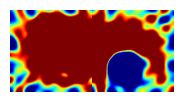

Ground Truth at timestep 900


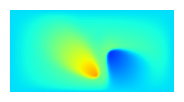

Error at timestep 900


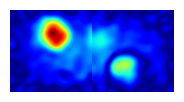

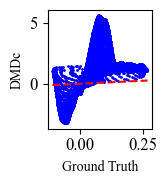

RMSE at timestep 900: 1.291690


In [198]:
import numpy as np
import matplotlib.pyplot as plt
import pydmd

# ==================================================
# USER SETTINGS
# ==================================================
nx = 100
ny = 200

svd_rank = 0
number_of_training_samples = 100
index = 900   # timestep you want to visualize

# ==================================================
# DATASET BLOCK
# Change only this part for another dataset
# ==================================================
GT = burgers_data
FullData = burgers_CS_data
FullU = burgers_input_Data

# variable name to store prediction
output_variable_name = "burgers_dmdonly_pred"

# ==================================================
# SHAPE CHECK
# ==================================================
n_states, n_total_steps = FullData.shape

if GT.shape[0] != n_states:
    raise ValueError("GT and FullData must have the same number of rows.")

if nx * ny != n_states:
    raise ValueError(f"nx*ny = {nx*ny}, but number of states = {n_states}.")

if index <= number_of_training_samples:
    raise ValueError("index must be greater than number_of_training_samples.")

if index >= n_total_steps:
    raise ValueError("index is larger than available timesteps.")

print("GT shape:      ", GT.shape)
print("FullData shape:", FullData.shape)
print("FullU shape:   ", FullU.shape)
print("Training steps:", number_of_training_samples)
print("Prediction up to timestep:", index)

# ==================================================
# TRAIN DMDc MODEL
# ==================================================
Data = FullData[:, :number_of_training_samples]
U = FullU[:, :number_of_training_samples - 1]

dmd = pydmd.DMDc(svd_rank=svd_rank)
dmd.fit(Data, U)

# ==================================================
# REDUCED MATRICES
# ==================================================
U_r = dmd.basis
A_tilde = dmd._Atilde.as_numpy_array
B_tilde = U_r.T @ dmd.B

print("Reduced rank:", U_r.shape[1])

# ==================================================
# DMDc-ONLY PREDICTION
# Predict from timestep number_of_training_samples to index
# ==================================================
dmdonly_pred = np.zeros((n_states, index + 1))
rmse_vec = np.zeros(index + 1)

# start from the last available CS state
last_full_state = FullData[:, number_of_training_samples].copy()

# store initial prediction timestep
dmdonly_pred[:, number_of_training_samples] = last_full_state.real
rmse_vec[number_of_training_samples] = np.sqrt(
    np.mean((last_full_state.real - GT[:, number_of_training_samples])**2)
)

for time in range(number_of_training_samples + 1, index + 1):

    u_k = FullU[:, time - 1]

    last_state_small = U_r.T @ last_full_state
    pred_small = A_tilde @ last_state_small + B_tilde @ u_k

    Pred = U_r @ pred_small
    Pred = Pred.real

    dmdonly_pred[:, time] = Pred
    rmse_vec[time] = np.sqrt(np.mean((Pred - GT[:, time])**2))

    last_full_state = Pred.copy()

# store variable using your selected name
globals()[output_variable_name] = dmdonly_pred

print(f"{output_variable_name} shape:", dmdonly_pred.shape)
print(f"RMSE at timestep {index}: {rmse_vec[index]:.6f}")

# ==================================================
# VISUALIZATION AT THE GIVEN INDEX
# ==================================================
Pred_plot = dmdonly_pred[:, index]
GT_plot = GT[:, index]
Err_plot = np.abs(Pred_plot - GT_plot)

print(f"Prediction at timestep {index}")

plt.figure(figsize=(2, 2))
plt.axis("off")
plt.imshow(Pred_plot.reshape(nx, ny), cmap="jet", vmin=GT.min(), vmax=GT.max())
# #plt.colorbar
# plt.title(f"DMDc Prediction, t={index}")
plt.tight_layout()
plt.show()

print(f"Ground Truth at timestep {index}")

plt.figure(figsize=(2, 2))
plt.axis("off")
plt.imshow(GT_plot.reshape(nx, ny), cmap="jet", vmin=GT.min(), vmax=GT.max())
#plt.colorbar
# plt.title(f"Ground Truth, t={index}")
plt.tight_layout()
plt.show()

print(f"Error at timestep {index}")

plt.figure(figsize=(2, 2))
plt.axis("off")
plt.imshow(Err_plot.reshape(nx, ny), cmap="jet")
#plt.colorbar
# plt.title(f"Absolute Error, t={index}")
plt.tight_layout()
plt.show()

# ==================================================
# SCATTER PLOT
# ==================================================
plt.figure(figsize=(2, 2))
plt.scatter(GT_plot, Pred_plot, color="blue", s=1)

# min_val = min(np.min(GT_plot), np.min(Pred_plot))
# max_val = max(np.max(GT_plot), np.max(Pred_plot))
GT_min_val = GT_plot.min()
GT_max_val = GT_plot.max()
Pred_min_val = Pred_plot.min()
Pred_max_val = Pred_plot.max()

plt.plot([GT_min_val, GT_max_val], [GT_min_val, GT_max_val], color="red", linestyle="--")
plt.xlabel("Ground Truth", fontsize=10)
plt.ylabel("DMDc", fontsize=10)
plt.tight_layout()
plt.show()

print(f"RMSE at timestep {index}: {rmse_vec[index]:.6f}")

#### Heat

GT shape:       (10201, 1000)
FullData shape: (10201, 1000)
FullU shape:    (4, 1000)
Training steps: 100
Prediction up to timestep: 900
Reduced rank: 10
heat_dmdonly_pred shape: (10201, 901)
RMSE at timestep 900: 21729363903618753516160806854337458671586087148334294061191004160.000000
Prediction at timestep 900


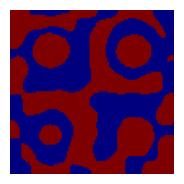

Ground Truth at timestep 900


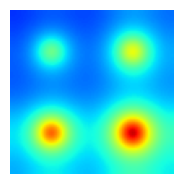

Error at timestep 900


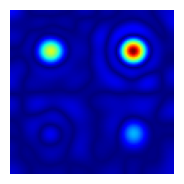

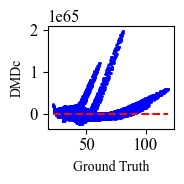

RMSE at timestep 900: 21729363903618753516160806854337458671586087148334294061191004160.000000


In [195]:
import numpy as np
import matplotlib.pyplot as plt
import pydmd

# ==================================================
# USER SETTINGS
# ==================================================
nx = 101
ny = 101

svd_rank = 10
number_of_training_samples = 100
index = 900   # timestep you want to visualize

# ==================================================
# DATASET BLOCK
# Change only this part for another dataset
# ==================================================
GT = heat_data
FullData = heat_CS_data
FullU = heat_input_Data

# variable name to store prediction
output_variable_name = "heat_dmdonly_pred"

# ==================================================
# SHAPE CHECK
# ==================================================
n_states, n_total_steps = FullData.shape

if GT.shape[0] != n_states:
    raise ValueError("GT and FullData must have the same number of rows.")

if nx * ny != n_states:
    raise ValueError(f"nx*ny = {nx*ny}, but number of states = {n_states}.")

if index <= number_of_training_samples:
    raise ValueError("index must be greater than number_of_training_samples.")

if index >= n_total_steps:
    raise ValueError("index is larger than available timesteps.")

print("GT shape:      ", GT.shape)
print("FullData shape:", FullData.shape)
print("FullU shape:   ", FullU.shape)
print("Training steps:", number_of_training_samples)
print("Prediction up to timestep:", index)

# ==================================================
# TRAIN DMDc MODEL
# ==================================================
Data = FullData[:, :number_of_training_samples]
U = FullU[:, :number_of_training_samples - 1]

dmd = pydmd.DMDc(svd_rank=svd_rank)
dmd.fit(Data, U)

# ==================================================
# REDUCED MATRICES
# ==================================================
U_r = dmd.basis
A_tilde = dmd._Atilde.as_numpy_array
B_tilde = U_r.T @ dmd.B

print("Reduced rank:", U_r.shape[1])

# ==================================================
# DMDc-ONLY PREDICTION
# Predict from timestep number_of_training_samples to index
# ==================================================
dmdonly_pred = np.zeros((n_states, index + 1))
rmse_vec = np.zeros(index + 1)

# start from the last available CS state
last_full_state = FullData[:, number_of_training_samples].copy()

# store initial prediction timestep
dmdonly_pred[:, number_of_training_samples] = last_full_state.real
rmse_vec[number_of_training_samples] = np.sqrt(
    np.mean((last_full_state.real - GT[:, number_of_training_samples])**2)
)

for time in range(number_of_training_samples + 1, index + 1):

    u_k = FullU[:, time - 1]

    last_state_small = U_r.T @ last_full_state
    pred_small = A_tilde @ last_state_small + B_tilde @ u_k

    Pred = U_r @ pred_small
    Pred = Pred.real

    dmdonly_pred[:, time] = Pred
    rmse_vec[time] = np.sqrt(np.mean((Pred - GT[:, time])**2))

    last_full_state = Pred.copy()

# store variable using your selected name
globals()[output_variable_name] = dmdonly_pred

print(f"{output_variable_name} shape:", dmdonly_pred.shape)
print(f"RMSE at timestep {index}: {rmse_vec[index]:.6f}")

# ==================================================
# VISUALIZATION AT THE GIVEN INDEX
# ==================================================
Pred_plot = dmdonly_pred[:, index]
GT_plot = GT[:, index]
Err_plot = np.abs(Pred_plot - GT_plot)

print(f"Prediction at timestep {index}")

plt.figure(figsize=(2, 2))
plt.axis("off")
plt.imshow(Pred_plot.reshape(nx, ny), cmap="jet", vmin=GT.min(), vmax=GT.max())
#plt.colorbar
# plt.title(f"DMDc Prediction, t={index}")
plt.tight_layout()
plt.show()

print(f"Ground Truth at timestep {index}")

plt.figure(figsize=(2, 2))
plt.axis("off")
plt.imshow(GT_plot.reshape(nx, ny), cmap="jet", vmin=GT.min(), vmax=GT.max())
#plt.colorbar
# plt.title(f"Ground Truth, t={index}")
plt.tight_layout()
plt.show()

print(f"Error at timestep {index}")

plt.figure(figsize=(2, 2))
plt.axis("off")
plt.imshow(Err_plot.reshape(nx, ny), cmap="jet")
#plt.colorbar
# plt.title(f"Absolute Error, t={index}")
plt.tight_layout()
plt.show()

# ==================================================
# SCATTER PLOT
# ==================================================
plt.figure(figsize=(2, 2))
plt.scatter(GT_plot, Pred_plot, color="blue", s=1)

GT_min_val = GT_plot.min()
GT_max_val = GT_plot.max()
Pred_min_val = Pred_plot.min()
Pred_max_val = Pred_plot.max()

plt.plot([GT_min_val, GT_max_val], [GT_min_val, GT_max_val], color="red", linestyle="--")
plt.xlabel("Ground Truth", fontsize=10)
plt.ylabel("DMDc", fontsize=10)
plt.tight_layout()
plt.show()

print(f"RMSE at timestep {index}: {rmse_vec[index]:.6f}")

#### SST

GT shape:       (28800, 365)
FullData shape: (28800, 150)
Training steps: 50
Prediction up to timestep: 300
Reduced rank: 10
U_r shape: (28800, 10)
A_tilde shape: (10, 10)
sst_dmdonly_pred shape: (28800, 301)
RMSE at timestep 300: 18463.525015
Prediction at timestep 300


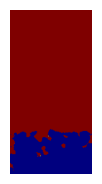

Ground Truth at timestep 300


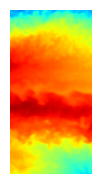

Error at timestep 300


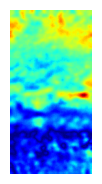

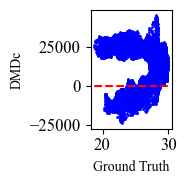

RMSE at timestep 300: 18463.525015


In [203]:
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# USER SETTINGS
# ==================================================
nx = 240
ny = 120

svd_rank = 10
number_of_training_samples = 50
index = 300   # timestep you want to visualize

# ==================================================
# DATASET BLOCK
# Change only this part for another dataset
# ==================================================
GT = sst_data
FullData = sst_CS_data

# variable name to store prediction
output_variable_name = "sst_dmdonly_pred"

# ==================================================
# SHAPE CHECK
# ==================================================
n_states, n_total_steps = GT.shape

if FullData.shape[0] != n_states:
    raise ValueError("GT and FullData must have the same number of rows.")

if nx * ny != n_states:
    raise ValueError(f"nx*ny = {nx * ny}, but number of states = {n_states}.")

if number_of_training_samples >= FullData.shape[1]:
    raise ValueError(
        f"number_of_training_samples = {number_of_training_samples}, "
        f"but FullData has only {FullData.shape[1]} timesteps."
    )

if index <= number_of_training_samples:
    raise ValueError("index must be greater than number_of_training_samples.")

if index >= n_total_steps:
    raise ValueError(
        f"index = {index} is larger than available GT timesteps. "
        f"Maximum available index is {n_total_steps - 1}."
    )

print("GT shape:      ", GT.shape)
print("FullData shape:", FullData.shape)
print("Training steps:", number_of_training_samples)
print("Prediction up to timestep:", index)

# ==================================================
# TRAIN STANDARD DMD MODEL MANUALLY
# ==================================================
Data = FullData[:, :number_of_training_samples]

# DMD snapshot pairs
X = Data[:, :-1]   # x_0 to x_48 if training samples = 50
Y = Data[:, 1:]    # x_1 to x_49

# SVD of X
U_svd, S_svd, Vh_svd = np.linalg.svd(X, full_matrices=False)

# Rank selection
if svd_rank == 0:
    tol = 1e-10
    r = np.sum(S_svd > tol)
else:
    r = svd_rank

U_r = U_svd[:, :r]
S_r = S_svd[:r]
V_r = Vh_svd.conj().T[:, :r]

# Reduced DMD operator
A_tilde = U_r.T @ Y @ V_r @ np.diag(1 / S_r)

print("Reduced rank:", r)
print("U_r shape:", U_r.shape)
print("A_tilde shape:", A_tilde.shape)

# ==================================================
# DMD-ONLY PREDICTION
# Predict from timestep number_of_training_samples to index
# ==================================================
dmdonly_pred = np.zeros((n_states, index + 1))
rmse_vec = np.zeros(index + 1)

# start from the last available CS state
last_full_state = FullData[:, number_of_training_samples].copy()

# store initial prediction timestep
dmdonly_pred[:, number_of_training_samples] = last_full_state.real

rmse_vec[number_of_training_samples] = np.sqrt(
    np.mean((last_full_state.real - GT[:, number_of_training_samples]) ** 2)
)

for time in range(number_of_training_samples + 1, index + 1):

    # project current state to reduced coordinates
    last_state_small = U_r.T @ last_full_state

    # one-step DMD prediction in reduced space
    pred_small = A_tilde @ last_state_small

    # lift back to full space
    Pred = U_r @ pred_small
    Pred = Pred.real

    # store prediction
    dmdonly_pred[:, time] = Pred

    # compute RMSE
    rmse_vec[time] = np.sqrt(
        np.mean((Pred - GT[:, time]) ** 2)
    )

    # update state for next step
    last_full_state = Pred.copy()

# store variable using your selected name
globals()[output_variable_name] = dmdonly_pred

print(f"{output_variable_name} shape:", dmdonly_pred.shape)
print(f"RMSE at timestep {index}: {rmse_vec[index]:.6f}")

# ==================================================
# VISUALIZATION AT THE GIVEN INDEX
# ==================================================
Pred_plot = dmdonly_pred[:, index]
GT_plot = GT[:, index]
Err_plot = np.abs(Pred_plot - GT_plot)

print(f"Prediction at timestep {index}")

plt.figure(figsize=(2, 2))
plt.axis("off")
plt.imshow(
    Pred_plot.reshape(nx, ny),
    cmap="jet",
    vmin=GT.min(),
    vmax=GT.max()
)
#plt.colorbar
plt.tight_layout()
plt.show()

print(f"Ground Truth at timestep {index}")

plt.figure(figsize=(2, 2))
plt.axis("off")
plt.imshow(
    GT_plot.reshape(nx, ny),
    cmap="jet",
    vmin=GT.min(),
    vmax=GT.max()
)
#plt.colorbar
plt.tight_layout()
plt.show()

print(f"Error at timestep {index}")

plt.figure(figsize=(2, 2))
plt.axis("off")
plt.imshow(
    Err_plot.reshape(nx, ny),
    cmap="jet"
)
#plt.colorbar
plt.tight_layout()
plt.show()

# ==================================================
# SCATTER PLOT
# ==================================================
plt.figure(figsize=(2, 2))
plt.scatter(GT_plot, Pred_plot, color="blue", s=1)
GT_min_val = GT_plot.min()
GT_max_val = GT_plot.max()
Pred_min_val = Pred_plot.min()
Pred_max_val = Pred_plot.max()

plt.plot([GT_min_val, GT_max_val], [GT_min_val, GT_max_val], color="red", linestyle="--")

# plt.plot(
#     [GT_min_val, GT_max_val], [Pred_min_val, Pred_max_val],
#     color="red",
#     linestyle="--"
# )

plt.xlabel("Ground Truth", fontsize=10)
plt.ylabel("DMDc", fontsize=10)
plt.tight_layout()
plt.show()

print(f"RMSE at timestep {index}: {rmse_vec[index]:.6f}")

In [199]:
import os

# Give your directory path here
directory = "Paper Figures/DMDc Only"

# Print all file names in the directory
for name in os.listdir(directory):
    full_path = os.path.join(directory, name)

    if os.path.isfile(full_path):
        print(name)

heatPred110.png
sstGT150.png
burgersGT150.png
sstScatter150.png
burgersScatter150.png
.DS_Store
sstScatter55.png
heatScatter900.png
burgersScatter900.png
burgersPred110.png
heatGT900.png
sstPred55.png
burgersGT900.png
sstPred150.png
burgersGT110.png
heatGT110.png
sstGT55.png
burgersPred900.png
burgersScatter110.png
burgersPred150.png
heatScatter110.png
heatPred900.png


# RMSE Figures

#### Heat

GT shape:       (10201, 1000)
FullData shape: (10201, 1000)
FullU shape:    (4, 1000)
Training steps: 100
Prediction up to timestep: 999
Reduced rank: 46
heat_dmdonly_pred shape: (10201, 1000)
RMSE at timestep 999: 1088.900060
Prediction at timestep 999


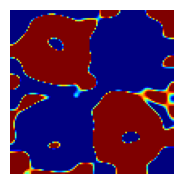

Ground Truth at timestep 999


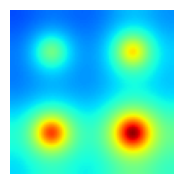

Error at timestep 999


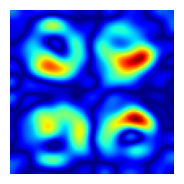

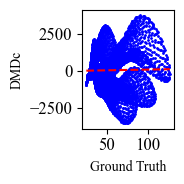

RMSE at timestep 999: 1088.900060


In [213]:
import numpy as np
import matplotlib.pyplot as plt
import pydmd
RMSE_VECTOR = []
# ==================================================
# USER SETTINGS
# ==================================================
nx = 101
ny = 101

svd_rank = 0
number_of_training_samples = 100
index = 999   # timestep you want to visualize

# ==================================================
# DATASET BLOCK
# Change only this part for another dataset
# ==================================================
GT = heat_data
FullData = heat_CS_data
FullU = heat_input_Data

# variable name to store prediction
output_variable_name = "heat_dmdonly_pred"

# ==================================================
# SHAPE CHECK
# ==================================================
n_states, n_total_steps = FullData.shape

if GT.shape[0] != n_states:
    raise ValueError("GT and FullData must have the same number of rows.")

if nx * ny != n_states:
    raise ValueError(f"nx*ny = {nx*ny}, but number of states = {n_states}.")

if index <= number_of_training_samples:
    raise ValueError("index must be greater than number_of_training_samples.")

if index >= n_total_steps:
    raise ValueError("index is larger than available timesteps.")

print("GT shape:      ", GT.shape)
print("FullData shape:", FullData.shape)
print("FullU shape:   ", FullU.shape)
print("Training steps:", number_of_training_samples)
print("Prediction up to timestep:", index)

# ==================================================
# TRAIN DMDc MODEL
# ==================================================
Data = FullData[:, :number_of_training_samples]
U = FullU[:, :number_of_training_samples - 1]

dmd = pydmd.DMDc(svd_rank=svd_rank)
dmd.fit(Data, U)

# ==================================================
# REDUCED MATRICES
# ==================================================
U_r = dmd.basis
A_tilde = dmd._Atilde.as_numpy_array
B_tilde = U_r.T @ dmd.B

print("Reduced rank:", U_r.shape[1])

# ==================================================
# DMDc-ONLY PREDICTION
# Predict from timestep number_of_training_samples to index
# ==================================================
dmdonly_pred = np.zeros((n_states, index + 1))
rmse_vec = np.zeros(index + 1)

# start from the last available CS state
last_full_state = FullData[:, number_of_training_samples].copy()

# store initial prediction timestep
dmdonly_pred[:, number_of_training_samples] = last_full_state.real
rmse_vec[number_of_training_samples] = np.sqrt(
    np.mean((last_full_state.real - GT[:, number_of_training_samples])**2)
)


for time in range(number_of_training_samples + 1, index + 1):

    u_k = FullU[:, time - 1]

    last_state_small = U_r.T @ last_full_state
    pred_small = A_tilde @ last_state_small + B_tilde @ u_k

    Pred = U_r @ pred_small
    Pred = Pred.real

    dmdonly_pred[:, time] = Pred
    rmse_vec[time] = np.sqrt(np.mean((Pred - GT[:, time])**2))
    RMSE_VECTOR.append(np.sqrt(np.mean((Pred - GT[:, time])**2)))

    last_full_state = Pred.copy()

# store variable using your selected name
globals()[output_variable_name] = dmdonly_pred

print(f"{output_variable_name} shape:", dmdonly_pred.shape)
print(f"RMSE at timestep {index}: {rmse_vec[index]:.6f}")

# ==================================================
# VISUALIZATION AT THE GIVEN INDEX
# ==================================================
Pred_plot = dmdonly_pred[:, index]
GT_plot = GT[:, index]
Err_plot = np.abs(Pred_plot - GT_plot)

print(f"Prediction at timestep {index}")

plt.figure(figsize=(2, 2))
plt.axis("off")
plt.imshow(Pred_plot.reshape(nx, ny), cmap="jet", vmin=GT.min(), vmax=GT.max())
#plt.colorbar
# plt.title(f"DMDc Prediction, t={index}")
plt.tight_layout()
plt.show()

print(f"Ground Truth at timestep {index}")

plt.figure(figsize=(2, 2))
plt.axis("off")
plt.imshow(GT_plot.reshape(nx, ny), cmap="jet", vmin=GT.min(), vmax=GT.max())
#plt.colorbar
# plt.title(f"Ground Truth, t={index}")
plt.tight_layout()
plt.show()

print(f"Error at timestep {index}")

plt.figure(figsize=(2, 2))
plt.axis("off")
plt.imshow(Err_plot.reshape(nx, ny), cmap="jet")
#plt.colorbar
# plt.title(f"Absolute Error, t={index}")
plt.tight_layout()
plt.show()

# ==================================================
# SCATTER PLOT
# ==================================================
plt.figure(figsize=(2, 2))
plt.scatter(GT_plot, Pred_plot, color="blue", s=1)

GT_min_val = GT_plot.min()
GT_max_val = GT_plot.max()
Pred_min_val = Pred_plot.min()
Pred_max_val = Pred_plot.max()

plt.plot([GT_min_val, GT_max_val], [GT_min_val, GT_max_val], color="red", linestyle="--")
plt.xlabel("Ground Truth", fontsize=10)
plt.ylabel("DMDc", fontsize=10)
plt.tight_layout()
plt.show()

print(f"RMSE at timestep {index}: {rmse_vec[index]:.6f}")

In [214]:
rmse = RMSE_VECTOR

start = 101

print("\\addplot coordinates {")
for i, v in enumerate(rmse):
    print(f"({start + i},{v})")
print("};")

\addplot coordinates {
(101,0.32208133531217265)
(102,0.3209479518392066)
(103,0.3213177477153391)
(104,0.32320346691817786)
(105,0.3264116750284834)
(106,0.3311625973897188)
(107,0.33753308702354046)
(108,0.3457073732856577)
(109,0.3562857755881523)
(110,0.37007292470836944)
(111,0.3878789032563003)
(112,0.41032409121514524)
(113,0.43765562480262743)
(114,0.4696467460884445)
(115,0.5056526655104666)
(116,0.5447748556457377)
(117,0.5860384366925558)
(118,0.6285642104340764)
(119,0.6717107641194721)
(120,0.715142021889113)
(121,0.7587946385498548)
(122,0.8027553195391867)
(123,0.8470967617875815)
(124,0.8917412859594674)
(125,0.9364107066486356)
(126,0.9806785359358711)
(127,1.0240916969043636)
(128,1.0663002269809534)
(129,1.1071436545427855)
(130,1.1466717251809135)
(131,1.1851086137022333)
(132,1.222785026472093)
(133,1.2600649883553106)
(134,1.2972855098475393)
(135,1.3347187073054478)
(136,1.3725585019098547)
(137,1.4109271881710206)
(138,1.4498947905172668)
(139,1.489500975829599)

#### Burgers

GT shape:       (20000, 1000)
FullData shape: (20000, 1000)
FullU shape:    (1, 1000)
Training steps: 100
Prediction up to timestep: 999
Reduced rank: 43
burgers_dmdonly_pred shape: (20000, 1000)
RMSE at timestep 999: 1.863813
Prediction at timestep 999


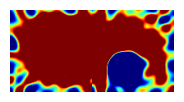

Ground Truth at timestep 999


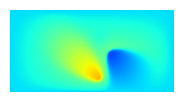

Error at timestep 999


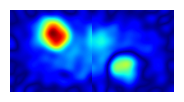

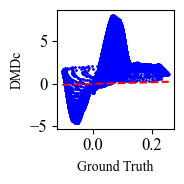

RMSE at timestep 999: 1.863813


In [218]:
import numpy as np
import matplotlib.pyplot as plt
import pydmd

RMSE_VECTOR = []
# ==================================================
# USER SETTINGS
# ==================================================
nx = 100
ny = 200
svd_rank = 0
number_of_training_samples = 100
index = 999   # timestep you want to visualize

# ==================================================
# DATASET BLOCK
# Change only this part for another dataset
# ==================================================
GT = burgers_data
FullData = burgers_CS_data
FullU = burgers_input_Data

# variable name to store prediction
output_variable_name = "burgers_dmdonly_pred"

# ==================================================
# SHAPE CHECK
# ==================================================
n_states, n_total_steps = FullData.shape

if GT.shape[0] != n_states:
    raise ValueError("GT and FullData must have the same number of rows.")

if nx * ny != n_states:
    raise ValueError(f"nx*ny = {nx*ny}, but number of states = {n_states}.")

if index <= number_of_training_samples:
    raise ValueError("index must be greater than number_of_training_samples.")

if index >= n_total_steps:
    raise ValueError("index is larger than available timesteps.")

print("GT shape:      ", GT.shape)
print("FullData shape:", FullData.shape)
print("FullU shape:   ", FullU.shape)
print("Training steps:", number_of_training_samples)
print("Prediction up to timestep:", index)

# ==================================================
# TRAIN DMDc MODEL
# ==================================================
Data = FullData[:, :number_of_training_samples]
U = FullU[:, :number_of_training_samples - 1]

dmd = pydmd.DMDc(svd_rank=svd_rank)
dmd.fit(Data, U)

# ==================================================
# REDUCED MATRICES
# ==================================================
U_r = dmd.basis
A_tilde = dmd._Atilde.as_numpy_array
B_tilde = U_r.T @ dmd.B

print("Reduced rank:", U_r.shape[1])

# ==================================================
# DMDc-ONLY PREDICTION
# Predict from timestep number_of_training_samples to index
# ==================================================
dmdonly_pred = np.zeros((n_states, index + 1))
rmse_vec = np.zeros(index + 1)

# start from the last available CS state
last_full_state = FullData[:, number_of_training_samples].copy()

# store initial prediction timestep
dmdonly_pred[:, number_of_training_samples] = last_full_state.real
rmse_vec[number_of_training_samples] = np.sqrt(
    np.mean((last_full_state.real - GT[:, number_of_training_samples])**2)
)

for time in range(number_of_training_samples + 1, index + 1):

    u_k = FullU[:, time - 1]

    last_state_small = U_r.T @ last_full_state
    pred_small = A_tilde @ last_state_small + B_tilde @ u_k

    Pred = U_r @ pred_small
    Pred = Pred.real

    dmdonly_pred[:, time] = Pred
    rmse_vec[time] = np.sqrt(np.mean((Pred - GT[:, time])**2))
    RMSE_VECTOR.append(np.sqrt(np.mean((Pred - GT[:, time])**2)))

    last_full_state = Pred.copy()

# store variable using your selected name
globals()[output_variable_name] = dmdonly_pred

print(f"{output_variable_name} shape:", dmdonly_pred.shape)
print(f"RMSE at timestep {index}: {rmse_vec[index]:.6f}")

# ==================================================
# VISUALIZATION AT THE GIVEN INDEX
# ==================================================
Pred_plot = dmdonly_pred[:, index]
GT_plot = GT[:, index]
Err_plot = np.abs(Pred_plot - GT_plot)

print(f"Prediction at timestep {index}")

plt.figure(figsize=(2, 2))
plt.axis("off")
plt.imshow(Pred_plot.reshape(nx, ny), cmap="jet", vmin=GT.min(), vmax=GT.max())
# #plt.colorbar
# plt.title(f"DMDc Prediction, t={index}")
plt.tight_layout()
plt.show()

print(f"Ground Truth at timestep {index}")

plt.figure(figsize=(2, 2))
plt.axis("off")
plt.imshow(GT_plot.reshape(nx, ny), cmap="jet", vmin=GT.min(), vmax=GT.max())
#plt.colorbar
# plt.title(f"Ground Truth, t={index}")
plt.tight_layout()
plt.show()

print(f"Error at timestep {index}")

plt.figure(figsize=(2, 2))
plt.axis("off")
plt.imshow(Err_plot.reshape(nx, ny), cmap="jet")
#plt.colorbar
# plt.title(f"Absolute Error, t={index}")
plt.tight_layout()
plt.show()

# ==================================================
# SCATTER PLOT
# ==================================================
plt.figure(figsize=(2, 2))
plt.scatter(GT_plot, Pred_plot, color="blue", s=1)

# min_val = min(np.min(GT_plot), np.min(Pred_plot))
# max_val = max(np.max(GT_plot), np.max(Pred_plot))
GT_min_val = GT_plot.min()
GT_max_val = GT_plot.max()
Pred_min_val = Pred_plot.min()
Pred_max_val = Pred_plot.max()

plt.plot([GT_min_val, GT_max_val], [GT_min_val, GT_max_val], color="red", linestyle="--")
plt.xlabel("Ground Truth", fontsize=10)
plt.ylabel("DMDc", fontsize=10)
plt.tight_layout()
plt.show()

print(f"RMSE at timestep {index}: {rmse_vec[index]:.6f}")

In [219]:
rmse = RMSE_VECTOR

start = 101

print("\\addplot coordinates {")
for i, v in enumerate(rmse):
    print(f"({start + i},{v})")
print("};")

\addplot coordinates {
(101,0.004509294500741962)
(102,0.004557406841510962)
(103,0.004606592047843688)
(104,0.004655218986488701)
(105,0.004702452481878667)
(106,0.004749719327502364)
(107,0.004799223936706651)
(108,0.004851920289087897)
(109,0.00490762592137077)
(110,0.004966577147584611)
(111,0.0050299552762265035)
(112,0.005098871459127438)
(113,0.005173400471536333)
(114,0.005252805784736075)
(115,0.005336450364072731)
(116,0.005424397338408933)
(117,0.005517399235029822)
(118,0.005616544204106888)
(119,0.0057227987320611845)
(120,0.005836588021783727)
(121,0.005957699853233837)
(122,0.006085725616561238)
(123,0.006220776637258318)
(124,0.006363896268823549)
(125,0.006516860274294853)
(126,0.006681599905246056)
(127,0.006859706352832571)
(128,0.007052248665790283)
(129,0.007259827539377212)
(130,0.007482708813667074)
(131,0.00772095944844348)
(132,0.007974561998451419)
(133,0.00824349464170293)
(134,0.008527783050255783)
(135,0.008827542887090718)
(136,0.00914300875213381)
(137,0.

#### SST

GT shape:       (28800, 365)
FullData shape: (28800, 150)
Training steps: 50
Prediction up to timestep: 360
Reduced rank: 49
U_r shape: (28800, 49)
A_tilde shape: (49, 49)
sst_dmdonly_pred shape: (28800, 361)
RMSE at timestep 360: 647707600.330221
Prediction at timestep 360


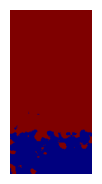

Ground Truth at timestep 360


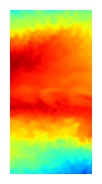

Error at timestep 360


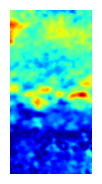

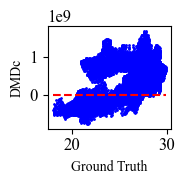

RMSE at timestep 360: 647707600.330221


In [222]:
import numpy as np
import matplotlib.pyplot as plt

RMSE_VECTOR = []

# ==================================================
# USER SETTINGS
# ==================================================
nx = 240
ny = 120

svd_rank = 0
number_of_training_samples = 50
index = 360   # timestep you want to visualize

# ==================================================
# DATASET BLOCK
# Change only this part for another dataset
# ==================================================
GT = sst_data
FullData = sst_CS_data

# variable name to store prediction
output_variable_name = "sst_dmdonly_pred"

# ==================================================
# SHAPE CHECK
# ==================================================
n_states, n_total_steps = GT.shape

if FullData.shape[0] != n_states:
    raise ValueError("GT and FullData must have the same number of rows.")

if nx * ny != n_states:
    raise ValueError(f"nx*ny = {nx * ny}, but number of states = {n_states}.")

if number_of_training_samples >= FullData.shape[1]:
    raise ValueError(
        f"number_of_training_samples = {number_of_training_samples}, "
        f"but FullData has only {FullData.shape[1]} timesteps."
    )

if index <= number_of_training_samples:
    raise ValueError("index must be greater than number_of_training_samples.")

if index >= n_total_steps:
    raise ValueError(
        f"index = {index} is larger than available GT timesteps. "
        f"Maximum available index is {n_total_steps - 1}."
    )

print("GT shape:      ", GT.shape)
print("FullData shape:", FullData.shape)
print("Training steps:", number_of_training_samples)
print("Prediction up to timestep:", index)

# ==================================================
# TRAIN STANDARD DMD MODEL MANUALLY
# ==================================================
Data = FullData[:, :number_of_training_samples]

# DMD snapshot pairs
X = Data[:, :-1]   # x_0 to x_48 if training samples = 50
Y = Data[:, 1:]    # x_1 to x_49

# SVD of X
U_svd, S_svd, Vh_svd = np.linalg.svd(X, full_matrices=False)

# Rank selection
if svd_rank == 0:
    tol = 1e-10
    r = np.sum(S_svd > tol)
else:
    r = svd_rank

U_r = U_svd[:, :r]
S_r = S_svd[:r]
V_r = Vh_svd.conj().T[:, :r]

# Reduced DMD operator
A_tilde = U_r.T @ Y @ V_r @ np.diag(1 / S_r)

print("Reduced rank:", r)
print("U_r shape:", U_r.shape)
print("A_tilde shape:", A_tilde.shape)

# ==================================================
# DMD-ONLY PREDICTION
# Predict from timestep number_of_training_samples to index
# ==================================================
dmdonly_pred = np.zeros((n_states, index + 1))
rmse_vec = np.zeros(index + 1)

# start from the last available CS state
last_full_state = FullData[:, number_of_training_samples].copy()

# store initial prediction timestep
dmdonly_pred[:, number_of_training_samples] = last_full_state.real

rmse_vec[number_of_training_samples] = np.sqrt(
    np.mean((last_full_state.real - GT[:, number_of_training_samples]) ** 2)
)

for time in range(number_of_training_samples + 1, index + 1):

    # project current state to reduced coordinates
    last_state_small = U_r.T @ last_full_state

    # one-step DMD prediction in reduced space
    pred_small = A_tilde @ last_state_small

    # lift back to full space
    Pred = U_r @ pred_small
    Pred = Pred.real

    # store prediction
    dmdonly_pred[:, time] = Pred

    # compute RMSE
    rmse_vec[time] = np.sqrt(
        np.mean((Pred - GT[:, time]) ** 2)
    )
    RMSE_VECTOR.append(np.sqrt(np.mean((Pred - GT[:, time]) ** 2)))
    # update state for next step
    last_full_state = Pred.copy()

# store variable using your selected name
globals()[output_variable_name] = dmdonly_pred

print(f"{output_variable_name} shape:", dmdonly_pred.shape)
print(f"RMSE at timestep {index}: {rmse_vec[index]:.6f}")

# ==================================================
# VISUALIZATION AT THE GIVEN INDEX
# ==================================================
Pred_plot = dmdonly_pred[:, index]
GT_plot = GT[:, index]
Err_plot = np.abs(Pred_plot - GT_plot)

print(f"Prediction at timestep {index}")

plt.figure(figsize=(2, 2))
plt.axis("off")
plt.imshow(
    Pred_plot.reshape(nx, ny),
    cmap="jet",
    vmin=GT.min(),
    vmax=GT.max()
)
#plt.colorbar
plt.tight_layout()
plt.show()

print(f"Ground Truth at timestep {index}")

plt.figure(figsize=(2, 2))
plt.axis("off")
plt.imshow(
    GT_plot.reshape(nx, ny),
    cmap="jet",
    vmin=GT.min(),
    vmax=GT.max()
)
#plt.colorbar
plt.tight_layout()
plt.show()

print(f"Error at timestep {index}")

plt.figure(figsize=(2, 2))
plt.axis("off")
plt.imshow(
    Err_plot.reshape(nx, ny),
    cmap="jet"
)
#plt.colorbar
plt.tight_layout()
plt.show()

# ==================================================
# SCATTER PLOT
# ==================================================
plt.figure(figsize=(2, 2))
plt.scatter(GT_plot, Pred_plot, color="blue", s=1)
GT_min_val = GT_plot.min()
GT_max_val = GT_plot.max()
Pred_min_val = Pred_plot.min()
Pred_max_val = Pred_plot.max()

plt.plot([GT_min_val, GT_max_val], [GT_min_val, GT_max_val], color="red", linestyle="--")

# plt.plot(
#     [GT_min_val, GT_max_val], [Pred_min_val, Pred_max_val],
#     color="red",
#     linestyle="--"
# )

plt.xlabel("Ground Truth", fontsize=10)
plt.ylabel("DMDc", fontsize=10)
plt.tight_layout()
plt.show()

print(f"RMSE at timestep {index}: {rmse_vec[index]:.6f}")

In [223]:
rmse = RMSE_VECTOR

start = 51

print("\\addplot coordinates {")
for i, v in enumerate(rmse):
    print(f"({start + i},{v})")
print("};")

\addplot coordinates {
(51,0.20535410910436638)
(52,0.2837710135829056)
(53,0.3855966150201686)
(54,0.5089658259022155)
(55,0.6393909170206743)
(56,0.7456753562116217)
(57,0.8450012018301858)
(58,0.9318472600199029)
(59,1.0220418360306331)
(60,1.1315974947606977)
(61,1.2797705760736051)
(62,1.4629482417053408)
(63,1.6658387839691722)
(64,1.9192389473422786)
(65,2.1484447731697935)
(66,2.3305641814992035)
(67,2.501630596856945)
(68,2.692878699169817)
(69,2.9189884965700363)
(70,3.1621718552403353)
(71,3.413043217572455)
(72,3.719186615857744)
(73,4.095928508426715)
(74,4.534782180060748)
(75,4.990469858825597)
(76,5.473157943880206)
(77,5.966248908339915)
(78,6.467144496679124)
(79,6.965316652309546)
(80,7.4991486108679455)
(81,8.10966174661139)
(82,8.788498143489793)
(83,9.510733091966923)
(84,10.271011202146374)
(85,11.070904092085005)
(86,11.925073256332203)
(87,12.845922061930514)
(88,13.830940240898627)
(89,14.913295111715751)
(90,16.071568288005587)
(91,17.29963632868342)
(92,18.5

# CS-DMDc-KF

SNR used            : 30 dB
Signal power        : 1048.091182
Noise power         : 1.048091
Noise std           : 1.023763
Number of sensors   : 51

DMD rank: 10
Max |λ(F)| after stabilisation: 0.999000

============================== EM iter 1
  ||Q_new − Q_old|| = 2.316309e+00

============================== EM iter 2
  ||Q_new − Q_old|| = 6.429735e-01

============================== EM iter 3
  ||Q_new − Q_old|| = 3.723679e-01

============================== EM iter 4
  ||Q_new − Q_old|| = 2.493697e-01

============================== EM iter 5
  ||Q_new − Q_old|| = 1.759747e-01

============================== EM iter 6
  ||Q_new − Q_old|| = 1.301423e-01

============================== EM iter 7
  ||Q_new − Q_old|| = 9.949550e-02

============================== EM iter 8
  ||Q_new − Q_old|| = 7.800351e-02

============================== EM iter 9
  ||Q_new − Q_old|| = 6.239484e-02

============================== EM iter 10
  ||Q_new − Q_old|| = 5.074665e-02

========================

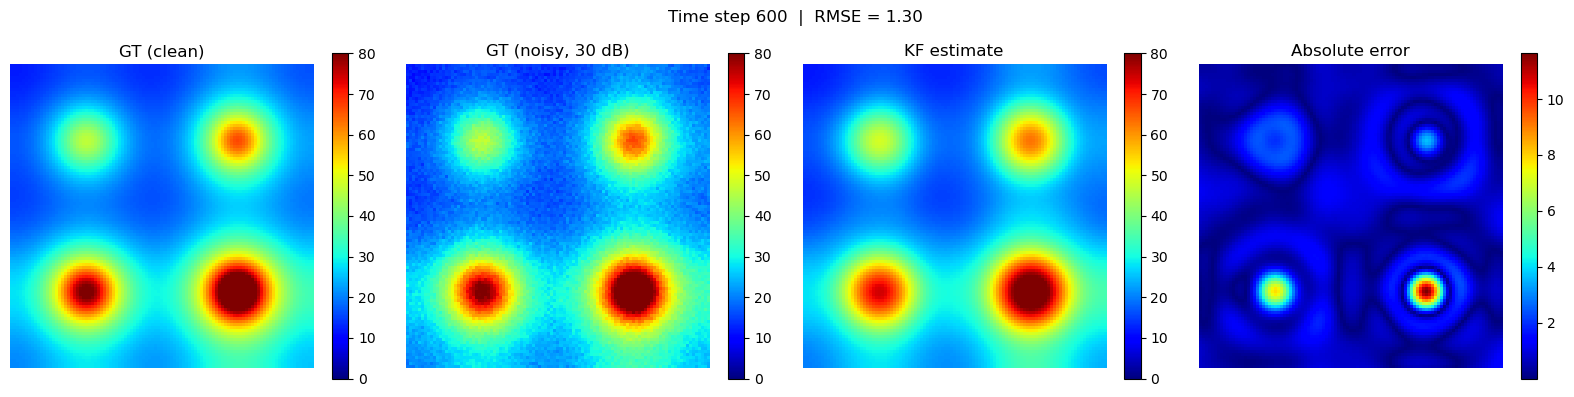

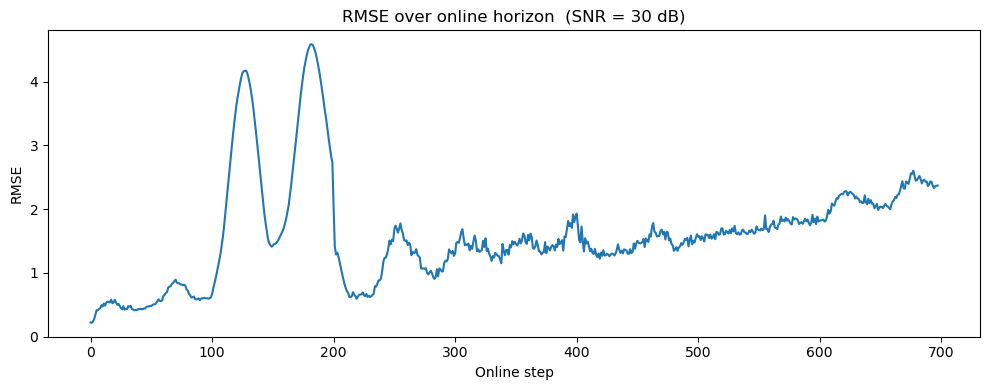

Final RMSE   : 2.3704
Average RMSE : 1.6154


In [ ]:
"""
CSDMD_KF_EM_DCCGARCH  —  FIXED VERSION
=======================================
All bugs that caused diverging RMSE are corrected.
Corrections are flagged with  # FIX N:  comments.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from collections import deque
from arch import arch_model
import warnings
import pydmd

warnings.filterwarnings("ignore")
# heat_data = pd.read_csv('heat_eq_new.csv', header=None).to_numpy()
# heat_CS_data = pd.read_csv('Reconstructed_State_Heat.csv', header=None).to_numpy()
# heat_input_Data = pd.read_csv('input_heat_eq_new.csv',header=None).to_numpy()

# ==================================================
# LOAD DATA
# ==================================================
GT         = pd.read_csv('heat_eq_new.csv',  header=None).to_numpy()
CS_Data    = pd.read_csv('Reconstructed_State_Heat.csv',  header=None).to_numpy()
input_Data = pd.read_csv('input_heat_eq_new.csv',           header=None).to_numpy()

GT_clean = GT.copy()
# Change nx, ny for other datasets
nx, ny = int(np.sqrt(GT.shape[0])), int(np.sqrt(GT.shape[0])) 
N = nx * ny

# ==================================================
# ADD NOISE  (FIX 6: use a realistic SNR, not −2000 dB)
# ==================================================
def add_awgn_snr(signal, snr_db, seed=42):
    rng = np.random.default_rng(seed)
    signal_power = np.mean(signal ** 2)
    snr_linear   = 10 ** (snr_db / 10.0)
    noise_power  = signal_power / snr_linear
    noise        = rng.normal(0.0, np.sqrt(noise_power), size=signal.shape)
    return signal + noise, noise, noise_power, np.sqrt(noise_power)

snr_db = 30   # FIX 6: was −2000 dB (pure noise) → 10 dB is a realistic noisy case
GT_noisy, GT_noise, noise_power_full, noise_std_full = add_awgn_snr(GT_clean, snr_db, seed=42)

print(f"SNR used            : {snr_db} dB")
print(f"Signal power        : {np.mean(GT_clean**2):.6f}")
print(f"Noise power         : {noise_power_full:.6f}")
print(f"Noise std           : {noise_std_full:.6f}")



# ==================================================
# SENSOR SELECTION MATRIX H
# ==================================================
p_sensor         = 0.005
m                = int(p_sensor * N)
number_of_sensors = m

np.random.seed(42)
H       = np.zeros((m, N))
indices = np.random.choice(N, m, replace=False)
for i, idx in enumerate(indices):
    H[i, idx] = 1

print(f"Number of sensors   : {m}")


# ==================================================
# HELPER: enforce Q positive-definite  (FIX 5)
# ==================================================
def make_pd(Q, eps=1e-8):
    """Symmetrise and clip any negative eigenvalues."""
    Q = 0.5 * (Q + Q.T)
    eigvals, eigvecs = np.linalg.eigh(Q)
    eigvals = np.maximum(eigvals, eps)
    return eigvecs @ np.diag(eigvals) @ eigvecs.T


# ==================================================
# FIX 8: stabilise the DMD operator F
# ==================================================
def stabilize_F(F, max_radius=0.999):
    """
    Project any eigenvalue with |λ| > max_radius back onto the unit circle.

    Why this matters
    ----------------
    DMD fits a linear operator to noisy snapshot data.  Even a single
    eigenvalue with |λ| > 1 causes the predict step
        x_{k+1|k} = F x_{k|k} + B u_k
    to amplify that mode at every step.  With only 0.5 % sensors the
    Kalman update cannot fully cancel the growth, so RMSE drifts upward
    regardless of how well Q and R are tuned.

    Approach: eigen-decompose F, scale any unstable eigenvalue to
    max_radius, reconstruct.  The imaginary parts of the stabilised F
    are at floating-point level and are discarded.
    """
    eigvals, eigvecs = np.linalg.eig(F)
    mags = np.abs(eigvals)
    # Scale down eigenvalues that sit outside the unit circle
    scale = np.where(mags > max_radius, max_radius / mags, 1.0)
    eigvals_stable = eigvals * scale
    F_stable = (eigvecs @ np.diag(eigvals_stable) @ np.linalg.inv(eigvecs)).real
    return F_stable


# ==================================================
# FIX 9: Q lower bound — never let Q fall below Q_floor
# ==================================================
def apply_Q_floor(Q, Q_floor, floor_fraction=0.05):
    """
    Ensure Q ≥ floor_fraction * Q_floor (element-wise in eigenspace).

    Why this matters
    ----------------
    DCC-GARCH can drive Q close to zero when residuals are small.
    A near-zero Q makes the filter over-trust the (imperfect) model
    and under-trust measurements, amplifying any model drift.
    Keeping Q ≥ 5 % of the EM-estimated Q_EM prevents this collapse.
    """
    Q_min = floor_fraction * Q_floor
    # Take the element-wise maximum in the PD sense (via eigendecomposition)
    eigvals_Q,   eigvecs_Q   = np.linalg.eigh(make_pd(Q))
    eigvals_min, _           = np.linalg.eigh(make_pd(Q_min))
    eigvals_out = np.maximum(eigvals_Q, eigvals_min)
    return eigvecs_Q @ np.diag(eigvals_out) @ eigvecs_Q.T


# ==================================================
# PART A: EM ALGORITHM — estimate initial Q_EM
# ==================================================

class KalmanDMDc:
    """Kalman filter used during EM training."""

    def __init__(self, dmd, GT, Input, U_r, Q, m=m, H=H):
        self.dmd   = dmd
        self.U_r   = U_r
        self.rank  = U_r.shape[1]
        self.Data  = GT
        self.Input = Input

        self.reduced_data = U_r.T @ self.Data
        self.B = U_r.T @ dmd.B
        self.F = dmd._Atilde.as_numpy_array

        self.N, self.timesteps = self.Data.shape
        self.m = m
        self.Q = Q
        self.H = H

        self.x = self.reduced_data[:, 0]
        self.P = U_r.T @ (10 * np.eye(self.N)) @ U_r
        self.R = 1e-3 * np.eye(self.m)

        self.X_pred     = []
        self.X_filtered = []
        self.P_pred     = []
        self.P_filtered = []

    def predict(self, u):
        self.x = self.F @ self.x + (self.B @ u).flatten()
        self.P = self.F @ self.P @ self.F.T + self.Q
        return self.x, self.P

    def update(self, z):
        HU  = self.H @ self.U_r
        S   = HU @ self.P @ HU.T + self.R
        K   = self.P @ HU.T @ np.linalg.inv(S)
        y   = z - HU @ self.x
        self.x = self.x + K @ y
        I   = np.eye(self.P.shape[0])
        # Correct Joseph form (unchanged — this class already had it right)
        IKH = I - K @ HU
        self.P = IKH @ self.P @ IKH.T + K @ self.R @ K.T
        return self.x, self.P

    def run(self):
        for k in range(self.timesteps - 1):
            u = self.Input[:, k]

            # Predict  →  x_{k+1|k}
            x_pred, P_pred = self.predict(u)
            self.X_pred.append(x_pred.real)
            self.P_pred.append(P_pred)

            # FIX 2: measurement must be at k+1, not k
            # (after predicting to k+1, we observe at k+1)
            z = self.H @ self.U_r @ self.reduced_data[:, k + 1]   # FIX 2

            x_upd, P_upd = self.update(z)
            self.X_filtered.append(x_upd.real)
            self.P_filtered.append(P_upd)

            self.x = x_upd
            self.P = P_upd

        X_pred_arr = np.array(self.X_pred).T
        X_filt_arr = np.array(self.X_filtered).T
        P_pred_arr = np.array(self.P_pred).transpose(1, 2, 0)
        P_filt_arr = np.array(self.P_filtered).transpose(1, 2, 0)

        return X_filt_arr, X_pred_arr, P_filt_arr, P_pred_arr


class KalmanSmoother:
    """RTS smoother used during EM."""

    def __init__(self, F, X_pred, X_filt, P_pred, P_filt):
        self.F      = F
        self.X_pred = X_pred
        self.X_filt = X_filt
        self.P_pred = P_pred
        self.P_filt = P_filt

    def smooth(self):
        r, T = self.X_filt.shape

        X_smooth = np.zeros_like(self.X_filt)
        P_smooth = np.zeros_like(self.P_filt)
        P_cross  = np.zeros_like(self.P_filt)

        X_smooth[:, -1]    = self.X_filt[:, -1]
        P_smooth[:, :, -1] = self.P_filt[:, :, -1]

        for k in range(T - 2, -1, -1):
            P_f      = self.P_filt[:, :, k]
            P_p_next = self.P_pred[:, :, k + 1]

            G = P_f @ self.F.T @ np.linalg.inv(P_p_next)

            X_smooth[:, k]    = self.X_filt[:, k] + G @ (X_smooth[:, k + 1] - self.X_pred[:, k + 1])
            P_smooth[:, :, k] = P_f + G @ (P_smooth[:, :, k + 1] - P_p_next) @ G.T
            P_cross[:, :, k]  = G @ P_smooth[:, :, k + 1]

        return X_smooth, P_smooth, P_cross


# ---------------------------------------------------
# EM training settings
# ---------------------------------------------------
kalman_start             = 300
number_of_training_samples = kalman_start

GT_train    = CS_Data[:, :number_of_training_samples]
Input_train = input_Data[:, :number_of_training_samples - 1]

dmd = pydmd.DMDc(svd_rank=10)
dmd.fit(GT_train, Input_train)

rank = dmd._Atilde.shape[0]
print(f"\nDMD rank: {rank}")

U_r = dmd.basis
F   = stabilize_F(dmd._Atilde.as_numpy_array)   # FIX 8: stabilise before EM loop
print(f"Max |λ(F)| after stabilisation: {np.max(np.abs(np.linalg.eigvals(F))):.6f}")

Q_new = make_pd(U_r.T @ np.eye(N) @ U_r)   # FIX 5: start PD
Q_old = Q_new.copy()

max_iter  = 1000
tolerance = 1e-6
norm_vec  = []

for iteration in range(max_iter):
    print(f"\n============================== EM iter {iteration + 1}")

    kf_em = KalmanDMDc(dmd, GT_train, Input_train, U_r, Q_new, m=m, H=H)
    X_filtered, X_pred, P_filtered, P_pred = kf_em.run()

    ks = KalmanSmoother(F, X_pred, X_filtered, P_pred, P_filtered)
    X_smooth, P_smooth, P_cross = ks.smooth()

    Q_old = Q_new.copy()

    Q_Sum = np.zeros((rank, rank))
    T_f   = X_filtered.shape[1]

    for k in range(T_f - 1):
        term = (
            P_smooth[:, :, k + 1]
            - F @ P_cross[:, :, k].T
            - P_cross[:, :, k] @ F.T
            + F @ P_smooth[:, :, k] @ F.T
        )
        Q_Sum += term

    Q_new = Q_Sum / (T_f - 1)   # FIX 3: was / T_f; sum has T_f−1 terms
    Q_new = make_pd(Q_new)       # FIX 5: enforce PD after M-step

    diff_norm = np.linalg.norm(Q_new - Q_old)
    norm_vec.append(diff_norm)
    print(f"  ||Q_new − Q_old|| = {diff_norm:.6e}")

    if diff_norm < tolerance:
        print(f"\nEM converged after {iteration + 1} iterations (norm = {diff_norm:.4e})")
        break

Q_EM = make_pd(Q_new)   # FIX 5
Q_floor = Q_EM.copy()   # FIX 9: save as the floor reference
print("\nFinal Q_EM:\n", Q_EM)


# ==================================================
# PART B: DCC-GARCH-BASED ONLINE Q UPDATES
# ==================================================

class KalmanFilter:
    """Online Kalman filter in reduced coordinates."""

    def __init__(self, F, B, H, Q, R, x0, P0, U_r):
        self.F   = F
        self.B   = B
        self.H   = H
        self.Q   = Q
        self.R   = R
        self.x   = x0
        self.P   = P0
        self.U_r = U_r

    def predict(self, u):
        self.x = self.F @ self.x + (self.B @ u).flatten()
        self.P = self.F @ self.P @ self.F.T + self.Q
        return self.x

    def update(self, z):
        HU  = self.H @ self.U_r
        S   = HU @ self.P @ HU.T + self.R
        K   = self.P @ HU.T @ np.linalg.inv(S)
        y   = z - HU @ self.x
        self.x = self.x + K @ y
        I   = np.eye(self.P.shape[0])
        # FIX 1: was missing the trailing @ IKH.T  — this was the main divergence cause
        IKH    = I - K @ HU
        self.P = IKH @ self.P @ IKH.T + K @ self.R @ K.T   # FIX 1
        return self.x, self.P


def estimate_Q_from_epsilons(eps_series, prev_Q=None):
    """DCC-GARCH(1,1) estimate of process noise covariance."""
    T, Nq = eps_series.shape
    if T < 20 or Nq == 0:
        return prev_Q if prev_Q is not None else 1e-3 * np.eye(Nq)

    cond_vol = np.zeros((T, Nq))
    eta      = np.zeros((T, Nq))

    for i in range(Nq):
        try:
            model = arch_model(eps_series[:, i], vol='Garch', p=1, q=1)
            fit   = model.fit(disp='off', show_warning=False)
            cond_vol[:, i] = fit.conditional_volatility
            eta[:, i]      = eps_series[:, i] / cond_vol[:, i]
        except Exception:
            std_i = max(np.std(eps_series[:, i]), 1e-12)
            cond_vol[:, i] = std_i
            eta[:, i]      = eps_series[:, i] / std_i

    bar_Q = np.cov(eta, rowvar=False)
    if np.ndim(bar_Q) == 0:
        bar_Q = np.array([[float(bar_Q)]])
    if np.linalg.det(bar_Q) <= 0:
        bar_Q += 1e-6 * np.eye(Nq)

    def dcc_nll(params, eta, bar_Q):
        a, b = params
        if a <= 0 or b <= 0 or (a + b) >= 1:
            return np.inf
        ll = 0.0
        Qt = bar_Q.copy()
        for t in range(T):
            if t > 0:
                Qt = (1 - a - b) * bar_Q + a * np.outer(eta[t-1], eta[t-1]) + b * Qt
            d = np.sqrt(np.diag(Qt))
            if np.any(d == 0):
                return np.inf
            R_t = Qt / np.outer(d, d)
            try:
                det = np.linalg.det(R_t)
                if det <= 0:
                    return np.inf
                ll += np.log(det) + eta[t] @ np.linalg.inv(R_t) @ eta[t]
            except Exception:
                return np.inf
        return ll

    res = minimize(dcc_nll, [0.02, 0.95], args=(eta, bar_Q),
                   method='L-BFGS-B', bounds=[(1e-6, 0.5), (1e-6, 0.99)])

    if not res.success:
        return prev_Q if prev_Q is not None else np.cov(eps_series, rowvar=False)

    a, b = res.x
    Qt = bar_Q.copy()
    Qt_series = [Qt]
    for t in range(1, T):
        Qt = (1 - a - b) * bar_Q + a * np.outer(eta[t-1], eta[t-1]) + b * Qt
        Qt_series.append(Qt)

    Qt_last = Qt_series[-1]
    d = np.sqrt(np.diag(Qt_last))
    if np.any(d == 0):
        return prev_Q if prev_Q is not None else np.cov(eps_series, rowvar=False)

    R_t = Qt_last / np.outer(d, d)
    D_t = np.diag(cond_vol[-1])
    H_t = D_t @ R_t @ D_t

    return make_pd(H_t)   # FIX 5: enforce PD on output


# ==================================================
# PREPARE ONLINE DATA
# ==================================================
Data_clean = GT_clean[:, kalman_start + 1:]
Data_noisy = GT_noisy[:, kalman_start + 1:]

# FIX 4: Input for the online per-step control.
# Data_clean[:, i] = GT at absolute time (kalman_start + 1 + i).
# At online step i we predict from that state, so control u_i is at
# absolute time (kalman_start + 1 + i).
Input = input_Data[:, kalman_start + 1:]    # FIX 4  — was input_Data[:, 100:-1]

N_full, timesteps = Data_clean.shape
print(f"\nOnline data shape : {Data_clean.shape}")
print(f"Input shape       : {Input.shape}")

B   = U_r.T @ dmd.B
print(f"B shape           : {B.shape}")

# Measurement noise covariance from actual injected noise at sensors
meas_noise    = H @ (GT_noisy - GT_clean)[:, kalman_start + 1:]
meas_var      = np.maximum(np.var(meas_noise, axis=1, ddof=1), 1e-10)
R             = np.diag(meas_var)
print(f"R shape           : {R.shape}, avg var = {np.mean(meas_var):.4e}")

reduced_clean = U_r.T @ Data_clean
x0 = reduced_clean[:, 0]
P0 = np.eye(rank) * 1

# Warm-start epsilon buffer from training residuals
init_red = U_r.T @ CS_Data[:, :kalman_start]
init_inp = input_Data[:, :kalman_start - 1]
init_eps = init_red[:, 1:] - F @ init_red[:, :-1] - B @ init_inp

epsilon_buffer = deque(maxlen=kalman_start)
for j in range(init_eps.shape[1]):
    epsilon_buffer.append(init_eps[:, j])

Q = estimate_Q_from_epsilons(init_eps.T, prev_Q=Q_EM)
Q = make_pd(Q)   # FIX 5
print(f"\nInitial online Q (EM + DCC-GARCH)\n{Q}")

update_freq = 10
min_window  = 50

mean_error        = []
rel_error         = []
rmse_vec          = []
RMSE_VECTOR       = []
updated_state_vec = np.zeros([N, kalman_start + timesteps + 1])
updated_state_vec[:, :kalman_start] = CS_Data[:, :kalman_start]

# ==================================================
# ONLINE FILTER + DCC-GARCH Q UPDATES
# ==================================================
for i in range(timesteps - 1):
    # ---- adaptive basis update every 100 steps ----
    if i % 100 == 0 and i != 0:
        dmd_new = pydmd.DMDc(svd_rank=rank)
        # FIX 4b: state window starts at absolute column i in updated_state_vec,
        # so the matching inputs must also use absolute indices from input_Data.
        # Using Input[:, i:...] is WRONG here because Input is already offset by
        # (kalman_start + 1), which shifts the slice by that amount and eventually
        # runs off the end of the array → "size 299 vs size 199" ValueError.
        dmd_new.fit(updated_state_vec[:, i:i + kalman_start],
                    input_Data[:, i:i + kalman_start - 1])  # FIX 4b
        prev_Ur = U_r.copy()
        U_r     = dmd_new.basis
        F       = stabilize_F(dmd_new._Atilde.as_numpy_array)   # FIX 8
        B       = U_r.T @ dmd_new.B
        reduced_clean = U_r.T @ Data_clean

        M  = U_r.T @ prev_Ur
        x0 = M @ x0
        P0 = M @ P0 @ M.T

        if len(epsilon_buffer) > 0:
            epsilon_buffer = deque([M @ e for e in epsilon_buffer], maxlen=kalman_start)

        old_Q   = Q.copy()
        Q_floor = M @ Q_floor @ M.T   # FIX 9: project floor into new basis too
        Q       = M @ old_Q @ M.T

        if len(epsilon_buffer) >= min_window:
            Q = estimate_Q_from_epsilons(np.array(list(epsilon_buffer)), prev_Q=old_Q)
            Q = make_pd(Q)
            Q = apply_Q_floor(Q, Q_floor)   # FIX 9
            print(f"  Refitted Q after basis update at step {i}")

    kf = KalmanFilter(F, B, H, Q, R, x0, P0, U_r)

    # Predict step
    u      = Input[:, i]
    kf.predict(u)
    pred_x = kf.x.copy()   # x_{i+1|i}

    # FIX 2: use measurement at i+1 (the time we just predicted to)
    z = H @ Data_noisy[:, i + 1]   # FIX 2  — was Data_noisy[:, i]

    # Update step
    updated_state = kf.update(z)
    x0 = updated_state[0]
    P0 = updated_state[1]

    # Process noise residual for DCC-GARCH buffer
    epsilon_t = x0 - pred_x
    epsilon_buffer.append(epsilon_t)

    # Periodic DCC-GARCH Q update
    if (i + 1) % update_freq == 0 and len(epsilon_buffer) >= min_window:
        Q = estimate_Q_from_epsilons(np.array(list(epsilon_buffer)), prev_Q=Q)
        Q = make_pd(Q)
        Q = apply_Q_floor(Q, Q_floor)   # FIX 9: prevent Q from collapsing
        print(f"  Updated Q at step {i + 1}")

    # ---- error metrics ----
    full_pred = (U_r @ x0).real
    # FIX 7: compare x̂_{i+1} with truth at i+1  — was Data_clean[:, i]
    full_true = Data_clean[:, i + 1]   # FIX 7

    rmse_full = np.sqrt(np.mean((full_pred - full_true) ** 2))
    mae_full  = np.mean(np.abs(full_pred - full_true))
    tre_full  = np.sum(100 * np.abs(full_pred - full_true)) / (np.sum(np.abs(full_true)) + 1e-12)

    rmse_vec.append(rmse_full)
    mean_error.append(mae_full)
    rel_error.append(tre_full)

    if i % 50 == 0:
        print(f"Step {i:4d}  RMSE={rmse_full:.4f}  MAE={mae_full:.4f}  RelErr={tre_full:.4f}%")

    updated_state_vec[:, kalman_start + i] = full_pred
    RMSE_VECTOR.append(rmse_full)

print("\nFiltering finished.")
print(f"Average RMSE: {np.mean(RMSE_VECTOR):.4f}")


# ==================================================
# PLOTS
# ==================================================
index = 600

gt_clean_img = GT_clean[:, index].reshape(nx, ny)
gt_noisy_img = GT_noisy[:, index].reshape(nx, ny)
pred_img     = updated_state_vec[:, index].reshape(nx, ny)
err_img      = np.abs(pred_img - gt_clean_img)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img, title in zip(
    axes,
    [gt_clean_img, gt_noisy_img, pred_img, err_img],
    ['GT (clean)', f'GT (noisy, {snr_db} dB)', 'KF estimate', 'Absolute error']
):
    im = ax.imshow(img, cmap='jet', vmin=0 if title != 'Absolute error' else None, vmax=80 if title != 'Absolute error' else None)
    ax.axis('off')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
plt.suptitle(f'Time step {index}  |  RMSE = {np.sqrt(np.mean((GT_clean[:, index] - updated_state_vec[:, index])**2)):.2f}')
plt.tight_layout()
plt.show()

# RMSE over time
plt.figure(figsize=(10, 4))
plt.plot(RMSE_VECTOR)
plt.xlabel('Online step')
plt.ylabel('RMSE')
plt.title(f'RMSE over online horizon  (SNR = {snr_db} dB)')
plt.tight_layout()
plt.show()

print(f"Final RMSE   : {RMSE_VECTOR[-1]:.4f}")
print(f"Average RMSE : {np.mean(RMSE_VECTOR):.4f}")